# Load model and simulation data

## Load model from checkpoint and store cleaned data

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from scipy import integrate
from scipy.stats import norm

import torch
import pytorch_lightning as pl

from sklearn.model_selection import train_test_split
import h5py

import sys
import os
sys.path.append(r"C:\Users\usuario\Documents\TFG\florah\src")

import florah
from florah import utils
from florah.models import rnn_model
from florah.models.rnn_model import rnn_generator
from florah.models.rnn_model.rnn_generator import DataModule 


from astropy.cosmology import Planck13
import astropy.units as u

import random
import pandas as pd
import seaborn as sns

In [2]:
# Load the trained model from a checkpoint file
checkpoint_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\last-v1.ckpt"  # Specify the path to your checkpoint file
loaded_model = DataModule.load_from_checkpoint(checkpoint_path,map_location='cpu', weights_only=False)

# Set the model to evaluation mode (important if you have dropout or batch normalization layers)
loaded_model.eval()

DataModule(
  (model): RecurrentMAF(
    (embedding_net): Identity()
    (rnn): ModuleList(
      (0): GRU(5, 128, batch_first=True)
      (1-3): 3 x GRU(128, 128, batch_first=True)
    )
    (maf_blocks): Flow(
      (_transform): CompositeTransform(
        (_transforms): ModuleList(
          (0): CompositeTransform(
            (_transforms): ModuleList(
              (0-3): 4 x CompositeTransform(
                (_transforms): ModuleList(
                  (0): MaskedAffineAutoregressiveTransform(
                    (autoregressive_net): MADE(
                      (initial_layer): MaskedLinear(in_features=3, out_features=128, bias=True)
                      (context_layer): Linear(in_features=128, out_features=128, bias=True)
                      (blocks): ModuleList(
                        (0-1): 2 x MaskedFeedforwardBlock(
                          (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
                          (line

#### Import "florah_eval_SFR_processed_cleaned_data.h5"

Usually takes less than 7 minutes, but it is needed to run `prepare_sims_data.py` at least once beforehand

In [3]:
data_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\"
raw_file_path = os.path.join(data_path, "projTNGEAGLESimbamstargt9_random_sizemassSFR_simname.h5")
# New file path for the optimized, cleaned data
processed_file_path = os.path.join(data_path, "florah_eval_SFR_processed_cleaned_data.h5")

In [4]:
# Load the data from the clean file into your lists
x = []
t = []
file = []

with h5py.File(processed_file_path, 'r') as hdf5_file:
    
    for group_name in hdf5_file:
        group = hdf5_file[group_name]
        
        x.append(group['x'][:])
        t.append(group['t'][:])
        
        # Decode the byte string back to regular string
        file.append(str(group.attrs['sim_name']))

print(f"Loaded {len(x)} groups ready for training.")

Loaded 707612 groups ready for training.


In [5]:
# Store 'x_copy' and 't' data as lists of NumPy arrays in the 'node_features' dictionary
node_features = {'x': [np.array(arr, dtype=np.float32) for arr in x], 't': [np.array(arr, dtype=np.float32) for arr in t]}

# Now, 'x' and 't' contain cleaned and converted data as NumPy arrays of objects
x = node_features['x']   # stellar mass, half mass radius and SFR
t = node_features['t']   # scale factor

# Split the data into training (85%) and validation (15%) sets
x_train, x_val, t_train, t_val = train_test_split(x, t, test_size=0.15, random_state=42)

x_train, x_val, t_train, t_val, file_train, file_val = train_test_split(x, t, file, test_size=0.15, random_state=42)
# Filter x_val and t_val where file_val is 'EAGLE'
eagle_indices = [i for i, sim in enumerate(file_val) if sim == 'EAGLE']
simba_indices = [i for i, sim in enumerate(file_val) if sim == 'Simba']
tng_indices = [i for i, sim in enumerate(file_val) if sim == 'TNG']

# Now extract only those entries from x_val and t_val
x_val_eagle = [x_val[i] for i in eagle_indices]
t_val_eagle = [t_val[i] for i in eagle_indices]

# Now extract only those entries from x_val and t_val
x_val_simba = [x_val[i] for i in simba_indices]
t_val_simba = [t_val[i] for i in simba_indices]

# Now extract only those entries from x_val and t_val
x_val_tng = [x_val[i] for i in tng_indices]
t_val_tng = [t_val[i] for i in tng_indices]


# Store 'x_copy' and 't' data as lists of NumPy arrays in the 'node_features' dictionary
node_features_train = {'x': [np.array(arr, dtype=np.float32) for arr in x_train], 't': [np.array(arr, dtype=np.float32) for arr in t_train]}
node_features_val = {'x': [np.array(arr, dtype=np.float32) for arr in x_val], 't': [np.array(arr, dtype=np.float32) for arr in t_val]}
node_features_val_eagle = {'x': [np.array(arr, dtype=np.float32) for arr in x_val_eagle], 't': [np.array(arr, dtype=np.float32) for arr in t_val_eagle]}
node_features_val_simba = {'x': [np.array(arr, dtype=np.float32) for arr in x_val_simba], 't': [np.array(arr, dtype=np.float32) for arr in t_val_simba]}
node_features_val_tng = {'x': [np.array(arr, dtype=np.float32) for arr in x_val_tng], 't': [np.array(arr, dtype=np.float32) for arr in t_val_tng]}

In [6]:
print('Num of sims from TNG:', len(tng_indices))
print('Num of sims from Eagle:', len(eagle_indices))
print('Num of sims from SIMBA:', len(simba_indices))
print(len(x))
print(len(file))
print(len(tng_indices)+len(eagle_indices)+len(simba_indices))

Num of sims from TNG: 31734
Num of sims from Eagle: 17029
Num of sims from SIMBA: 57379
707612
707612
106142


## Plot simulations

In [ ]:
plot_sims = r'C:\Users\usuario\Documents\TFG\florah_eval_SFR\plots_simulations\\'

This will give us an idea on how the simulations behave

In [ ]:
# plot a few examples
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True)

# plot the MAH and CAH of first 30 trees at each redshift
for i in range(0,30):
    z = 1 / t_val[i] - 1  # redshift
    axes[0].plot(z, np.array(x_val[i][:,0]).astype('float') , alpha=0.5)
    axes[1].plot(z,  np.array(x_val[i][:,1]).astype('float'), alpha=0.5)
    axes[2].plot(z,  np.array(x_val[i][:,2]).astype('float'), alpha=0.5)

axes[0].set_ylabel(r'$\log M_*/M_\odot$')
axes[1].set_ylabel(r'$\log R_h$')
axes[2].set_ylabel(r'$\log SFR$')
axes[0].set_xlabel(r'redshift $z$')
axes[1].set_xlabel(r'redshift $z$')
axes[2].set_xlabel(r'redshift $z$')
axes[0].invert_xaxis()
fig.tight_layout()
plt.savefig(plot_sims+'variation_validation.png')

In [ ]:
# plot a few examples
fig, axes = plt.subplots(1, 3, figsize=(8, 4), sharex=True)

# plot the MAH and CAH of first 40 trees at each redshift
for i in range(0,40):
    z = 1 / t_val_simba[i] - 1  # redshift
    axes[0].plot(z, np.array(x_val_simba[i][:,0]).astype('float') , alpha=0.5)
    axes[1].plot(z,  np.array(x_val_simba[i][:,1]).astype('float'), alpha=0.5)
    axes[2].plot(z,  np.array(x_val_simba[i][:,2]).astype('float'), alpha=0.5)

axes[0].set_ylabel(r'$\log M_*/M_\odot$')
axes[1].set_ylabel(r'$\log R_h$')
axes[2].set_ylabel(r'$\log SFR$')
axes[0].set_xlabel(r'redshift $z$')
axes[1].set_xlabel(r'redshift $z$')
axes[2].set_xlabel(r'redshift $z$')
axes[0].invert_xaxis()
fig.tight_layout()
plt.savefig(plot_sims+'variation_simba.png')



In [ ]:
# plot a few examples
fig, axes = plt.subplots(1, 3, figsize=(8, 4), sharex=True)

# plot the MAH and CAH of first 10 trees at each redshift
for i in range(0,40):
    z = 1 / t_val_eagle[i] - 1  # redshift
    axes[0].plot(z, np.array(x_val_eagle[i][:,0]).astype('float') , alpha=0.5)
    axes[1].plot(z,  np.array(x_val_eagle[i][:,1]).astype('float'), alpha=0.5)
    axes[2].plot(z,  np.array(x_val_eagle[i][:,2]).astype('float'), alpha=0.5)

axes[0].set_ylabel(r'$\log M_*/M_\odot$')
axes[1].set_ylabel(r'$\log R_h$')
axes[2].set_ylabel(r'$\log SFR$')
axes[0].set_xlabel(r'redshift $z$')
axes[1].set_xlabel(r'redshift $z$')
axes[2].set_xlabel(r'redshift $z$')
axes[0].invert_xaxis()
fig.tight_layout()
plt.savefig(plot_sims+'variation_eagle.png')



In [ ]:
# plot a few examples
fig, axes = plt.subplots(1, 3, figsize=(8, 4), sharex=True)

# plot the MAH and CAH of first 10 trees at each redshift
for i in range(0,40):
    z = 1 / t_val_tng[i] - 1  # redshift
    axes[0].plot(z, np.array(x_val_tng[i][:,0]).astype('float') , alpha=0.5)
    axes[1].plot(z,  np.array(x_val_tng[i][:,1]).astype('float'), alpha=0.5)
    axes[2].plot(z,  np.array(x_val_tng[i][:,2]).astype('float'), alpha=0.5)

axes[0].set_ylabel(r'$\log M_*/M_\odot$')
axes[1].set_ylabel(r'$\log R_h$')
axes[2].set_ylabel(r'$\log SFR$')
axes[0].set_xlabel(r'redshift $z$')
axes[1].set_xlabel(r'redshift $z$')
axes[2].set_xlabel(r'redshift $z$')
axes[0].invert_xaxis()
fig.tight_layout()
plt.savefig(plot_sims+'variation_tng.png')


In [ ]:
node_features['t'][0]

for i in range(200):
    plt.plot(np.array(node_features_val_tng['x'][i][:,0]),np.array(node_features_val_tng['x'][i][:,2]))

plt.xlabel(r"$\log M_*/M_\odot$",fontsize=20)    
plt.ylabel(r"$\log SFR$",fontsize=20) 

plt.savefig(plot_sims+'logSFR-vs-logM_TNG.png')

In [ ]:
node_features['t'][0]

for i in range(200):
    plt.plot(np.array(node_features_val_simba['x'][i][:,0]),np.array(node_features_val_simba['x'][i][:,2]))

plt.xlabel(r"$\log M_*/M_\odot$",fontsize=20)    
plt.ylabel(r"$\log SFR$",fontsize=20) 
plt.savefig(plot_sims+'logSFR-vs-logM_simba.png')


In [ ]:
node_features['t'][0]

for i in range(200):
    plt.plot(np.array(node_features_val_eagle['x'][i][:,0]),np.array(node_features_val_eagle['x'][i][:,2]))

plt.xlabel(r"$\log M_*/M_\odot$",fontsize=20)    
plt.ylabel(r"$\log SFR$",fontsize=20) 

plt.savefig(plot_sims+'logSFR-vs-logM_eagle.png')


## Sample trees from trained model and compare with simulations

#### Plotting ground truth and sampled trees

The following algorithm is implemented to generate the simulation data, given the stellar mass, sersic radius and SFR at initial redshift.

In [ ]:
# Now we can sample the trees from the trained model.
n_trees = 50

# We first need to define the roots of the trees, which are the initial
# mass and concentration of the halos.
# for this tutorial we will just reuse the roots of the training trees
root = x_val[5][0]
roots = np.tile(root, (n_trees, 1))


# We also need to define the redshifts at which we want to sample the trees.
redshifts = np.array([0,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,6])
scale_factors = 1 / (1 + redshifts)
scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
scale_factors = scale_factors[..., np.newaxis]

# sample the trees
sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)

For each simulation type (TNG, Simba and EAGLE) we will take a number `num_elements` of simulations, which we will name "ground truth" in the following", and compare them to the generated data by the model `sampled_trees`. Not only we will plot these curves in order to have a visual cue of the comparison between the ground truth and the sampled trees, but also we will do an statistical analysis on these results to further compare them.

##### TNG

In [ ]:
# Number of elements to plot from x_val
num_elements = 2
start_index = 460

# Create a grid of plots (num_elements rows, 3 columns)
fig, axes = plt.subplots(num_elements, 3, figsize=(18*3, 18*num_elements))


# Iterate over the elements of x_val and create subplots
for i,pos in enumerate(range(start_index,start_index+num_elements)):
    # Now we can sample the trees for the current element of x_val
    n_trees = 50
    root = x_val_tng[pos][0]
    roots = np.tile(root, (n_trees, 1))

    z_init = (1 / t_val_tng[pos] - 1 )[0].item()
    z_init = min(z_init, 6)  # Ensure starting value does not exceed 6ç
    
    # Create the redshifts array
    redshifts = np.arange(z_init, 6.5, 0.5)  # 6.5 as the stop value ensures inclusion of 6 if it's within the step range

    scale_factors = 1 / (1 + redshifts)
    scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
    scale_factors = scale_factors[..., np.newaxis]

    # Sample the trees for the current element of x_val
    sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)
    means_trees = np.mean(sampled_trees, axis=0) # Mean model prediction on the grid.
    median_trees = np.median(sampled_trees, axis=0)



    # Plot the MAH and CAH of the i-th element of x_val
    for j in range(n_trees):
        z = 1 / scale_factors[j] - 1  # redshift
        axes[i, 0].plot(z, sampled_trees[j][:, 0], c='dimgray', alpha=0.5)
        axes[i, 1].plot(z, sampled_trees[j][:, 1], c='dimgray', alpha=0.5)
        axes[i, 2].plot(z, sampled_trees[j][:, 2], c='dimgray', alpha=0.5)
        #axes[i, 2].plot(sampled_trees[j][:, 0], sampled_trees[j][:, 1], c='k', alpha=0.5)

    
    # Plot mean of all trees
    z = 1 / scale_factors[0] - 1
    axes[i, 0].plot(z, means_trees[:, 0], c='g', lw=4, label='Mean')
    axes[i, 1].plot(z, means_trees[:, 1], c='g', lw=4, label='Mean')
    axes[i, 2].plot(z, means_trees[:, 2], c='g', lw=4, label='Mean')

    # Plot median of all trees
    z = 1 / scale_factors[0] - 1
    axes[i, 0].plot(z, median_trees[:, 0], c='b', ls='-', lw=4, label='Median')
    axes[i, 1].plot(z, median_trees[:, 1], c='b', ls='-', lw=4, label='Median')
    axes[i, 2].plot(z, median_trees[:, 2], c='b', ls='-', lw=4, label='Median')


    # Plot the redshift and size/mass from x_val
    z = 1 / t_val_tng[pos] - 1 #- (1 / t_val_tng[pos][0] - 1)  redshift
    axes[i, 0].plot(z, np.array(x_val_tng[pos][:, 0]).astype('float'), c='red', lw=4)
    axes[i, 1].plot(z, np.array(x_val_tng[pos][:, 1]).astype('float'), c='red', lw=4)
    axes[i, 2].plot(z, np.array(x_val_tng[pos][:, 2]).astype('float'), c='red', lw=4)
    #axes[i, 2].plot(np.array(x_val[i][:, 0]).astype('float'), np.array(x_val[i][:, 1]).astype('float'), color='red', lw=4)

    axes[i, 0].legend()
    # Set axis labels and tick label size
    axes[i, 0].set_ylabel(r'$\log_{10}(M_\mathrm{*} / M_\odot)$', fontsize=100)
    axes[i, 1].set_ylabel(r'$\log re$', fontsize=100)
    axes[i, 0].set_xlabel(r'redshift $z$', fontsize=100)
    axes[i, 1].set_xlabel(r'redshift $z$', fontsize=100)
    axes[i, 2].set_xlabel(r'redshift $z$', fontsize=100)
    #axes[i, 2].set_xlabel(r'$\log_{10}(M_\mathrm{*} / M_\odot)$', fontsize=100)
    axes[i, 2].set_ylabel(r'$\log SFR$', fontsize=100)
    # Increase the size of tick labels
    for ax in axes[i, :]:
        ax.tick_params(axis='both', labelsize=50)
        ax.grid(True, which='major', linestyle='--', alpha=0.9)


    




# Tight layout for better spacing
fig.tight_layout()
plt.savefig(plot_sims+'sampled_trees_tng.png')


# Show the plot
plt.show()


##### SIMBA

In [ ]:
# Number of elements to plot from x_val
num_elements = 3
start_index = 55

# Create a grid of plots (num_elements rows, 3 columns)
fig, axes = plt.subplots(num_elements, 3, figsize=(18*3, 18*num_elements))

# Iterate over the elements of x_val and create subplots
for i,pos in enumerate(range(start_index,start_index+num_elements)):
    # Now we can sample the trees for the current element of x_val
    n_trees = 50
    root = x_val_simba[pos][0]
    roots = np.tile(root, (n_trees, 1))

    z_init = (1 / t_val_simba[pos] - 1 )[0].item()
    z_init = min(z_init, 6)  # Ensure starting value does not exceed 6
    
    # Create the redshifts array
    redshifts = np.arange(z_init, 6.5, 0.5)  # 6.5 as the stop value ensures inclusion of 6 if it's within the step range
    scale_factors = 1 / (1 + redshifts)
    scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
    scale_factors = scale_factors[..., np.newaxis]

    # Sample the trees for the current element of x_val
    sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)
    means_trees = np.mean(sampled_trees, axis=0) # Mean model prediction on the grid.

    # Plot the MAH and CAH of the i-th element of x_val
    for j in range(n_trees):
        z = 1 / scale_factors[j] - 1  # redshift
        axes[i, 0].plot(z, sampled_trees[j][:, 0], c='dimgray', alpha=0.5)
        axes[i, 1].plot(z, sampled_trees[j][:, 1], c='dimgray', alpha=0.5)
        axes[i, 2].plot(z, sampled_trees[j][:, 2], c='dimgray', alpha=0.5)
        #axes[i, 2].plot(sampled_trees[j][:, 0], sampled_trees[j][:, 1], c='k', alpha=0.5)


    # Plot mean of all trees
    z = 1 / scale_factors[0] - 1
    axes[i, 0].plot(z, means_trees[:, 0], c='k', alpha=1)
    axes[i, 1].plot(z, means_trees[:, 1], c='k', alpha=1)
    axes[i, 2].plot(z, means_trees[:, 2], c='k', alpha=1)

    
    # Plot the redshift and size/mass from x_val
    z = 1 / t_val_simba[pos] - 1 # - (1 / t_val_simba[pos][0] - 1) # redshift
    axes[i, 0].plot(z, np.array(x_val_simba[pos][:, 0]).astype('float'), c='red', lw=4)
    axes[i, 1].plot(z, np.array(x_val_simba[pos][:, 1]).astype('float'), c='red', lw=4)
    axes[i, 2].plot(z, np.array(x_val_simba[pos][:, 2]).astype('float'), c='red', lw=4)
    #axes[i, 2].plot(np.array(x_val[i][:, 0]).astype('float'), np.array(x_val[i][:, 1]).astype('float'), color='red', lw=4)

    # Set axis labels and tick label size
    axes[i, 0].set_ylabel(r'$\log_{10}(M_\mathrm{*} / M_\odot)$', fontsize=100)
    axes[i, 1].set_ylabel(r'$\log re$', fontsize=100)
    axes[i, 0].set_xlabel(r'redshift $z$', fontsize=100)
    axes[i, 1].set_xlabel(r'redshift $z$', fontsize=100)
    axes[i, 2].set_xlabel(r'redshift $z$', fontsize=100)
    #axes[i, 2].set_xlabel(r'$\log_{10}(M_\mathrm{*} / M_\odot)$', fontsize=100)
    axes[i, 2].set_ylabel(r'$\log SFR$', fontsize=100)

    # Increase the size of tick labels
    for ax in axes[i, :]:
        ax.tick_params(axis='both', labelsize=20)
        ax.grid(True, which='major', linestyle='--', alpha=0.9)

    # Invert x-axis for the first column
    #axes[i, 0].invert_xaxis()

# Tight layout for better spacing
fig.tight_layout()

# Save the plot
plt.savefig(plot_sims+'sampled_trees_simba.png')


# Show the plot
plt.show()


##### Eagle

In [ ]:
# Number of elements to plot from x_val
num_elements = 3

# Create a grid of plots (num_elements rows, 3 columns)
fig, axes = plt.subplots(num_elements, 3, figsize=(18*3, 18*num_elements))

# Iterate over the elements of x_val and create subplots
for i,pos in enumerate(range(3,3+num_elements)):
    # Now we can sample the trees for the current element of x_val
    n_trees = 50
    root = x_val_eagle[pos][0]
    roots = np.tile(root, (n_trees, 1))

    #redshifts = np.array([0,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,6])
    z_init = (1 / t_val_eagle[pos] -1)[0].item()
    z_init = min(z_init, 6)  # Ensure starting value does not exceed 6
    

    # Create the redshifts array
    redshifts = np.arange(z_init, 9, 1)  # 9 as the stop value ensures inclusion of 8 if it's within the step range

    scale_factors = 1 / (1 + redshifts)
    scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
    scale_factors = scale_factors[..., np.newaxis]

    # Sample the trees for the current element of x_val
    sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)
    means_trees = np.mean(sampled_trees, axis=0) # Mean model prediction on the grid.

    # Plot the MAH and CAH of the i-th element of x_val
    for j in range(n_trees):
        axes[i, 0].plot(redshifts, sampled_trees[j][:, 0], c='dimgray', alpha=0.5)
        axes[i, 1].plot(redshifts, sampled_trees[j][:, 1], c='dimgray', alpha=0.5)
        axes[i, 2].plot(redshifts, sampled_trees[j][:, 2], c='dimgray', alpha=0.5)
        #axes[i, 2].plot(sampled_trees[j][:, 0], sampled_trees[j][:, 1], c='k', alpha=0.5)


    # Plot mean of all trees
    z = 1 / scale_factors[0] - 1
    axes[i, 0].plot(z, means_trees[:, 0], c='k', alpha=1)
    axes[i, 1].plot(z, means_trees[:, 1], c='k', alpha=1)
    axes[i, 2].plot(z, means_trees[:, 2], c='k', alpha=1)

    
    # Plot the redshift and size/mass from x_val
    z = 1 / t_val_eagle[pos] - 1  #- (1 / t_val_eagle[pos][0] - 1) # redshift
    axes[i, 0].plot(z, np.array(x_val_eagle[pos][:, 0]).astype('float'), c='red', lw=4)
    axes[i, 1].plot(z, np.array(x_val_eagle[pos][:, 1]).astype('float'), c='red', lw=4)
    axes[i, 2].plot(z, np.array(x_val_eagle[pos][:, 2]).astype('float'), c='red', lw=4)
    #axes[i, 2].plot(np.array(x_val[i][:, 0]).astype('float'), np.array(x_val[i][:, 1]).astype('float'), color='red', lw=4)

    # Set axis labels and tick label size
    axes[i, 0].set_ylabel(r'$\log_{10}(M_\mathrm{*} / M_\odot)$', fontsize=100)
    axes[i, 1].set_ylabel(r'$\log re$', fontsize=100)
    axes[i, 0].set_xlabel(r'redshift $z$', fontsize=100)
    axes[i, 1].set_xlabel(r'redshift $z$', fontsize=100)
    axes[i, 2].set_xlabel(r'redshift $z$', fontsize=100)
    #axes[i, 2].set_xlabel(r'$\log_{10}(M_\mathrm{*} / M_\odot)$', fontsize=100)
    axes[i, 2].set_ylabel(r'$\log SFR$', fontsize=100)

    # Increase the size of tick labels
    for ax in axes[i, :]:
        ax.tick_params(axis='both', labelsize=50)
        ax.grid(True, which='major', linestyle='--', alpha=0.9)

    # Invert x-axis for the first column
    #axes[i, 0].invert_xaxis()

# Tight layout for better spacing
fig.tight_layout()

# Save the plot
plt.savefig(plot_sims+'sampled_trees_eagle.png')


# Show the plot
plt.show()


# Data analysis

### Calculate differences

We will do an estimation on how well does our model perform. In order to do so, we will calculate the difference

$$\Delta(z) = x_{GT}^z - \bar{x}_{\text{trees}}^z$$
at a given redshift $z$

where $x_{GT}$ represents the value of the stellar mass, size and SFR for the simulated histories, 
$\bar{x}_{trees}$ represents the mean value of those same properties but for the sampled trees.

In order to compute these differences $\Delta$, we will firstly need to compute the mean of all the sampled trees for each galaxy. For each $\bar{x}_{\text{trees}}$, we interpolate its value to the redshifts at which $x_{GT}^z$ is available.

Meanwhile, we will compute $$\Delta_{\text{med}}(z) = x_{GT}^z - \widetilde{x}_{\text{trees}}^z$$

where $\widetilde{x}_{\text{trees}}^z$ represents the median of the trees at a given redshift z, which might give us a different result.


The following cell takes 12s more less when `num_elements = 10`

When `num_elements=100` it took 1:30 min

For `num_elements=1000` it took 16min, and if `n_trees =100` it takes 25min

For `num_elements=10000` it took 142 min, with `n_trees = 50`, because doubling n_trees did not make a significant change but it takes double the time

##### Run locally

In [ ]:
num_elements = 100
start_index = 3

# Defining empty lists to do storing:

# master_z_list will be a 1D array
# master_diff_list will be an array with dims (N, 3)
# master_diff_median_list will be an array with dims (N, 3)

master_z_list = []
master_diff_list = []
master_diff_median_list = []

for i, pos in enumerate(range(start_index, start_index + num_elements)):
    # --- SAFETY CHECK: Skip empty galaxies ---
    if len(x_val[pos]) == 0:
        print(f"Skipping index {pos}: galaxy has no data (len=0).")
        continue 
    
    # --- A. Prepare data and sample trees ---
    n_trees = 50
    root = x_val[pos][0]
    roots = np.tile(root, (n_trees, 1))

    # We compute z_init to set up the model grid
    z_init_val = (1 / t_val[pos] - 1)[0].item()
    z_init_val = min(z_init_val, 6)
    
    # Redshift grid for model
    redshifts_model = np.arange(z_init_val, 6.5, 0.2) 

    scale_factors = 1 / (1 + redshifts_model)
    scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
    scale_factors = scale_factors[..., np.newaxis]

    sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)
    means_trees = np.mean(sampled_trees, axis=0) # Mean model prediction on the grid.
    median_trees = np.median(sampled_trees, axis=0)

    # --- B. Interpolate to simulation's grid ---
    z_val = 1 / t_val[pos] - 1 
    z_val = z_val.flatten()

    mean_interpolated = np.zeros_like(x_val[pos])
    median_interpolated = np.zeros_like(x_val[pos])

    for col in range(3):
        # We interpolate each physical property separately
        mean_interpolated[:, col] = np.interp(z_val, redshifts_model, means_trees[:, col])
        median_interpolated[:, col] = np.interp(z_val, redshifts_model, median_trees[:, col])

    # --- C. Calculate differences ---
    difference = x_val[pos] - mean_interpolated
    difference_median = x_val[pos] - median_interpolated

    # --- D. Storing ---
    # We do not append the entire matrix; instead, we extend the list.
    # This is important because otherwise we cannot compute the mean of the columns 
    # (if each galaxy has) different points to plot.
    master_z_list.extend(z_val)
    master_diff_list.extend(difference)
    master_diff_median_list.extend(difference_median)


# We convert to np.array in order to compute means later
all_z_numpy = np.array(master_z_list)                        # Shape: (N,)
all_diff_numpy = np.array(master_diff_list)                  # Shape: (N, 3)
all_diff_median_numpy = np.array(master_diff_median_list)    # Shape: (N, 3)


In [ ]:
# --- Change storing directory ---
# Specifying in which path I want the plots and diff data to be saved.
saving_path = r'C:\Users\usuario\Documents\TFG\florah_eval_SFR\\'
run_directory = 'num_elements='+str(num_elements)+' n_trees='+str(n_trees)

#Combine the paths safely
full_dir_path = os.path.join(saving_path, run_directory)

# create the directory if it doesn't exist yet
os.makedirs(full_dir_path, exist_ok=True)


We will store this calculation in a h5py file

In [ ]:
# Open a new HDF5 file ( 'w' for write)
with h5py.File(full_dir_path+'\\differences.h5py', 'w') as f:
    # Create datasets
    f.create_dataset('z_values', data=all_z_numpy, compression="gzip", compression_opts=5)
    f.create_dataset('diffs', data=all_diff_numpy, compression="gzip", compression_opts=5)
    f.create_dataset('median_diffs', data=all_diff_median_numpy, compression="gzip", compression_opts=5)
    
    # You can even add metadata (attributes)
    f.attrs['description'] = 'Model output comparison data - Differences'
    f.attrs['date'] = '2026-05-06'

##### Run in deimos

In [43]:
full_dir_path = r"C:\Users\usuario\Documents\TFG\florah_eval_SFR\num_elements=10000-n_trees=50\\"
differences_path = r"C:\Users\usuario\Documents\TFG\florah_eval_SFR\num_elements=10000-n_trees=50\differences.h5py"

num_elements = 10000

with h5py.File(differences_path, 'r') as f:
    all_z_numpy = f['z_values'][:]
    all_diff_numpy = f['diffs'][:]
    all_diff_median_numpy = f['median_diffs'][:]

In [44]:
print(all_z_numpy)
print(all_z_numpy.shape)

[1.5756004  1.6578355  1.7436197  ... 0.88689697 0.95053124 1.0355103 ]
(182258,)


##### Build histogram data

Although we have an overall error measurement, we now aim to analyze its dependence on redshift. For this purpose, we will build histograms that show the number of galaxies with a given error $\Delta$ at each redshift.

This is to prevent galaxies that do not exist at some redshift contribute to the mean. For example, if a galaxy A shows up at z=2, we do not want its "zero" values to contribute in the mean for z=3. Also, it is possible that we have 100 galaxies with values for z=2.11, but none for z=2, so, this way we make sure that every galaxy is contributing to the mean.

In [51]:
# --- Statistical binning ---
# Define bins where we want to evaluate the errors
z_bins = np.arange(0, 6.1, 0.1) # Adjust to your liking, the more points the better
bin_centers = []
mu_evolution = []
sigma_evolution = []

for i in range(len(z_bins) - 1):
    z_min = z_bins[i]
    z_max = z_bins[i+1]
    
    # Mask: We only take galaxies included in the bin. 
    mask = (all_z_numpy >= z_min) & (all_z_numpy < z_max)
    
    if np.any(mask): 
        diffs_in_bin = all_diff_numpy[mask] # Select only the data that fall in this bin
        
        # Calculate mean and standar deviation in each column (axis=0)
        mean_in_bin = np.mean(diffs_in_bin, axis=0)
        std_in_bin = np.std(diffs_in_bin, axis=0)
        
        mu_evolution.append(mean_in_bin)
        sigma_evolution.append(std_in_bin)
        bin_centers.append((z_min + z_max) / 2)
    else:
        # Optional: Fill with NaNs if bin is empty, in order to not break graphs (ideal is num_elements is low)
        mu_evolution.append([np.nan, np.nan, np.nan])
        sigma_evolution.append([np.nan, np.nan, np.nan])
        bin_centers.append((z_min + z_max) / 2)

# We convert to np.array in order to compute means later
mu_evolution = np.array(mu_evolution)       # Shape: (N_bins, 3)
sigma_evolution = np.array(sigma_evolution) # Shape: (N_bins, 3)
bin_centers = np.array(bin_centers)

print("mu_evolution shape:", mu_evolution.shape)
print("z_bins and bin_centers shape:", z_bins.shape, bin_centers.shape)

mu_evolution shape: (60, 3)
z_bins and bin_centers shape: (61,) (60,)


Doing the same, but now using $\Delta_{\text{med}(z)}$

In [52]:
# --- Statistical binning ---
# Define bins where we want to evaluate the errors
z_bins = np.arange(0, 6.5, 0.1) # Adjust to your liking, the more points the better
bin_centers_med = []
mu_evolution_med = []
sigma_evolution_med = []

for i in range(len(z_bins) - 1):
    z_min = z_bins[i]
    z_max = z_bins[i+1]
    
    # Mask: We only take galaxies included in the bin. 
    mask = (all_z_numpy >= z_min) & (all_z_numpy < z_max)
    
    if np.any(mask): 
        diffs_in_bin = all_diff_median_numpy[mask] # Select only the data that fall in this bin
        
        # Calculate mean and standar deviation in each column (axis=0)
        mean_in_bin = np.mean(diffs_in_bin, axis=0)
        std_in_bin = np.std(diffs_in_bin, axis=0)
        
        mu_evolution_med.append(mean_in_bin)
        sigma_evolution_med.append(std_in_bin)
        bin_centers_med.append((z_min + z_max) / 2)
    else:
        # Optional: Fill with NaNs if bin is empty, in order to not break graphs (ideal is num_elements is low)
        mu_evolution_med.append([np.nan, np.nan, np.nan])
        sigma_evolution_med.append([np.nan, np.nan, np.nan])
        bin_centers_med.append((z_min + z_max) / 2)

# We convert to np.array in order to compute means later
mu_evolution_med = np.array(mu_evolution_med)       # Shape: (N_bins, 3)
sigma_evolution_med = np.array(sigma_evolution_med) # Shape: (N_bins, 3)
bin_centers_med = np.array(bin_centers_med)

print("mu_evolution shape:", mu_evolution_med.shape)
print("z_bins and bin_centers shape:", z_bins.shape, bin_centers_med.shape)

mu_evolution shape: (64, 3)
z_bins and bin_centers shape: (65,) (64,)


#### Histogram plotting

Because `mu_evolution` has many points (ideally), it is not optimal to plot every redshift into a subplot. Instead we will choose an array `zs_targets` that include those "snapshots" at which we want to plot the histograms

Bin z~0.450: 9712 galaxies found.
Bin z~1.450: 6561 galaxies found.
Bin z~2.950: 775 galaxies found.
Bin z~4.450: 1607 galaxies found.


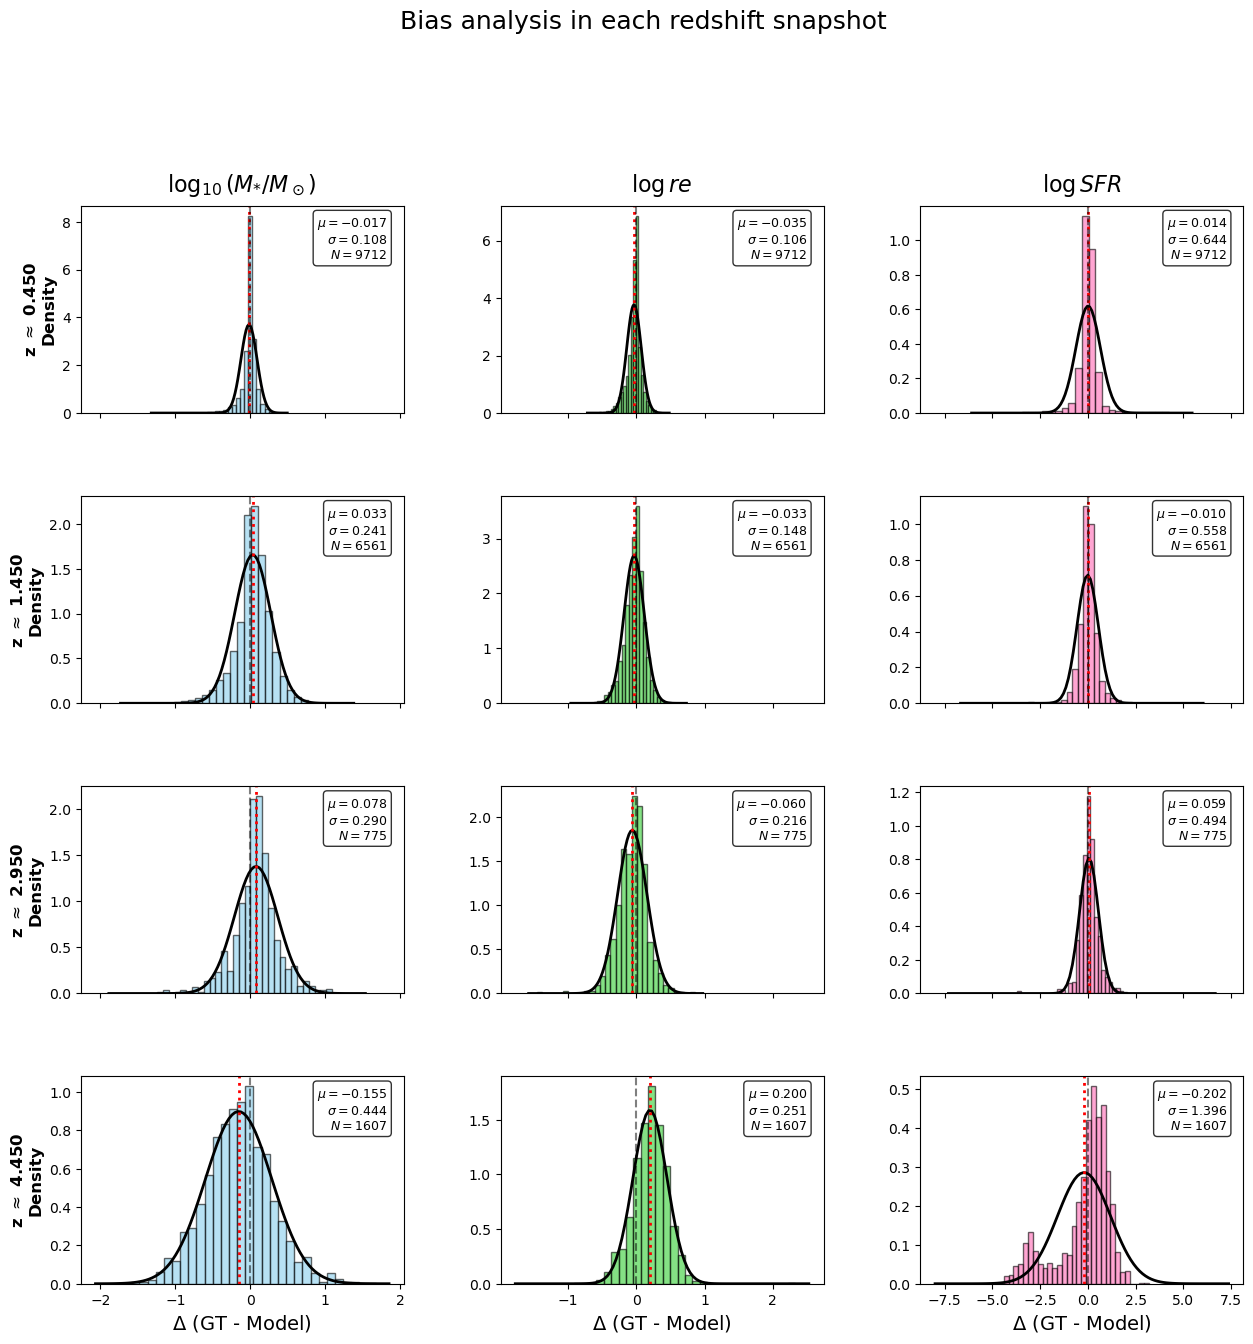

In [53]:
# --- 1. Snapshot configuration ---
# Choose in this array which redshifts you'd like to plot, they will be searched for in bin_centers
zs_targets = [0.5, 1.5, 3.0, 4.5] 


# Labels for the plots
props_names = [r'$\log_{10}(M_\mathrm{*} / M_\odot)$', r'$\log re$', r'$\log SFR$']
colors = ['skyblue', 'limegreen', 'hotpink']

# Search for index of those bins closer to the targets 
indices_to_plot = []
for z_t in zs_targets:
    idx = (np.abs(bin_centers - z_t)).argmin()
    if idx not in indices_to_plot:
        indices_to_plot.append(idx)

# --- 2. Plot configuration ---
# squeeze=False makes sure that axes_hist will always be 2D matrix [filas, cols]
# even if zs_target has 1 redshift.
n_rows = len(indices_to_plot)
fig_hist, axes_hist = plt.subplots(n_rows, 3, figsize=(15, 3.5 * n_rows), 
                                   sharex='col', squeeze=False)
plt.subplots_adjust(hspace=0.4, wspace=0.3)


for row_idx, bin_idx in enumerate(indices_to_plot):
    z_center = bin_centers[bin_idx]
    z_min = z_bins[bin_idx]
    z_max = z_bins[bin_idx+1]

    # We use mask to filter only data that fall in this bin
    mask = (all_z_numpy >= z_min) & (all_z_numpy < z_max)
    data_in_bin = all_diff_numpy[mask]
    n_samples = len(data_in_bin)
    
    # Warns if there is an empty bin (may happen if num_elements is low)
    if n_samples == 0:
        print(f"WARNING: bin centered in z={z_center:.3f} is EMPTY. Skipping plot.")
    else:
        print(f"Bin z~{z_center:.3f}: {n_samples} galaxies found.")

    for col in range(3):
        ax = axes_hist[row_idx, col]
        
        mu = mu_evolution[bin_idx, col]
        sigma = sigma_evolution[bin_idx, col]
        
        # If there is no data, we plot just that
        if n_samples < 2 or np.isnan(mu):
            ax.text(0.5, 0.5, "NO DATA / NAN", transform=ax.transAxes, 
                    ha='center', va='center', color='red', fontsize=12)
            if col == 0: ax.set_ylabel(f"z $\\approx$ {z_center:.3f}", fontweight='bold', fontsize=12)
            continue

        # --- HISTOGRAM ---
        # density=True normalizes to 1 so that we can compare to a gaussian later
        vals = data_in_bin[:, col]
        n, bins_hist, patches = ax.hist(vals, bins=30, color=colors[col], 
                                        edgecolor='black', alpha=0.6, density=True, label='Data')

        # We plot a gaussian with the same values of mu and sigma, so that we can check if our 
        # distribution matches with it
        xmin, xmax = ax.get_xlim()
        # We add a small margin if the data range is very narrow.
        if xmin == xmax: 
            xmin -= 0.1; xmax += 0.1
            
        x_plot = np.linspace(xmin, xmax, 100)
        
        if sigma > 0:
            y_plot = norm.pdf(x_plot, loc=mu, scale=sigma)
            ax.plot(x_plot, y_plot, 'k-', lw=2, label='Fit (Global)')
            ax.axvline(mu, color='r', linestyle=':', linewidth=2) 
            ax.axvline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.5) 


        # --- Decorate ---
        if row_idx == 0:
            ax.set_title(props_names[col], fontsize=16, pad=10)
            
        if col == 0:
            # Laber indicatind redshift of the bin
            ax.set_ylabel(f"z $\\approx$ {z_center:.3f}\nDensity", fontsize=12, fontweight='bold')

        # Show statistics (mean, sigma and n_samples in each bin)
        stats_text = f'$\\mu={mu:.3f}$\n$\\sigma={sigma:.3f}$\n$N={n_samples}$'
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=9, va='top', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# X axis labels at the bottom
for col in range(3):
    axes_hist[-1, col].set_xlabel(r'$\Delta$ (GT - Model)', fontsize=14)

fig_hist.suptitle(f"Bias analysis in each redshift snapshot", fontsize=18, y=1.02)
final_file_path = os.path.join(full_dir_path, 'histograms.png')
plt.savefig(final_file_path, bbox_inches='tight', dpi=500)
plt.show()

Doing the same, but now using $\Delta_{\text{med}(z)}$


Bin z~0.450: 9712 galaxies found.
Bin z~1.450: 6561 galaxies found.
Bin z~2.950: 775 galaxies found.
Bin z~4.450: 1607 galaxies found.


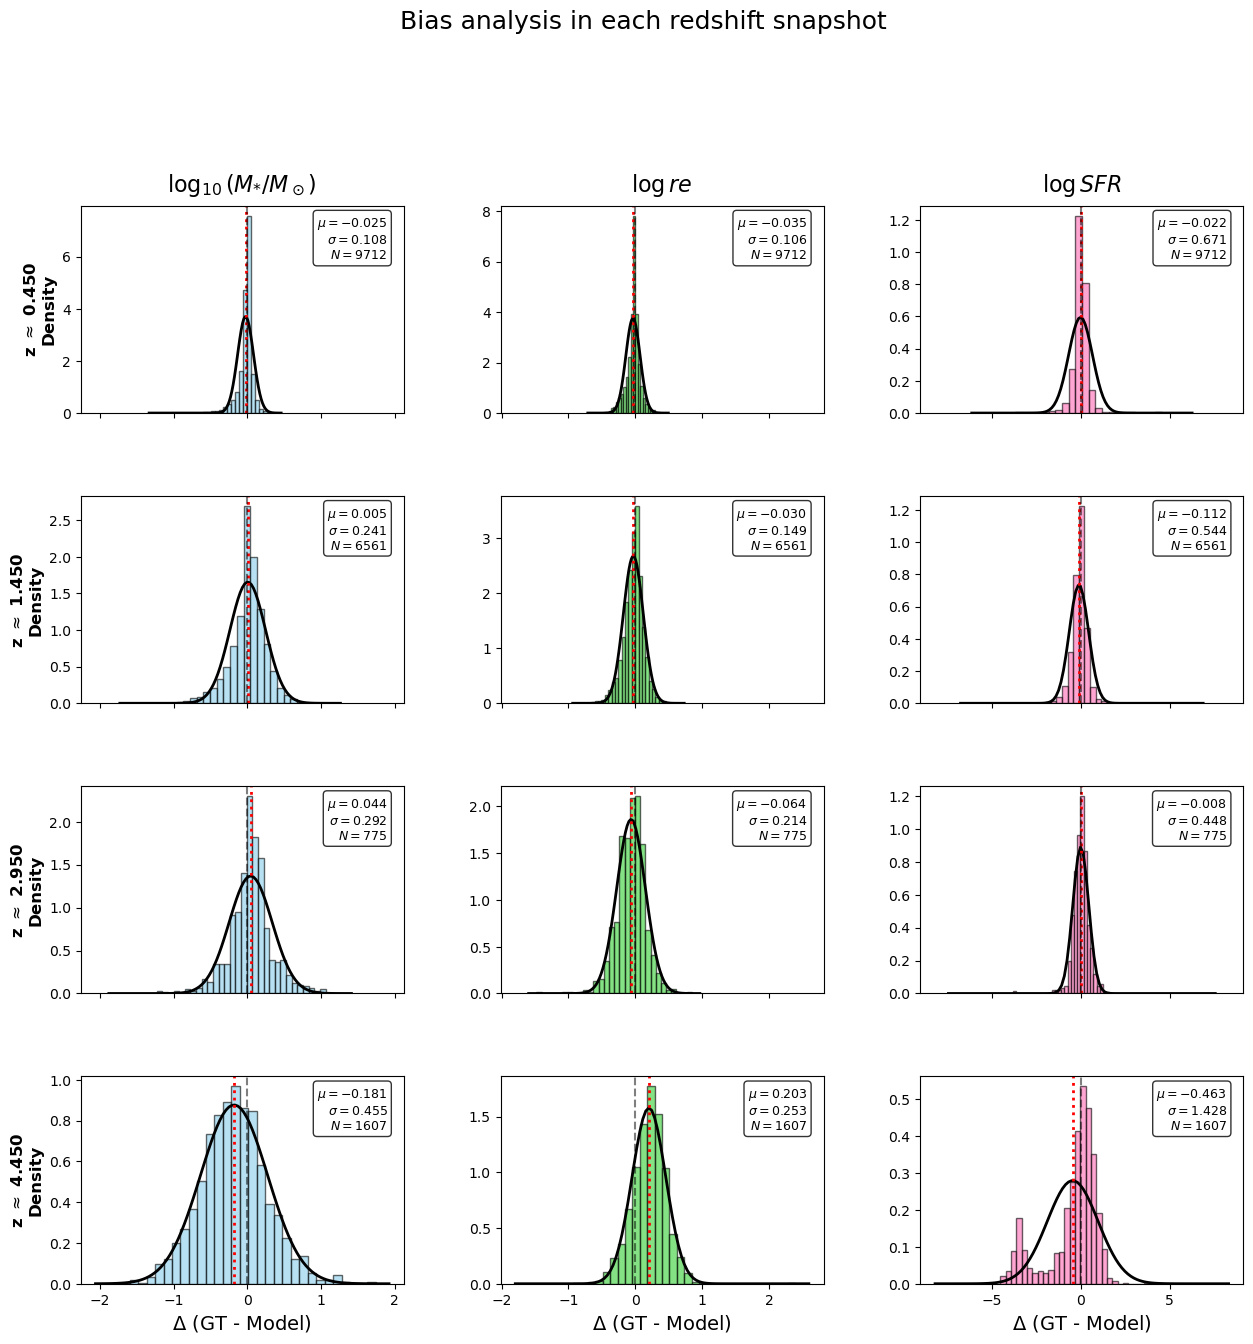

In [54]:
# --- 1. Snapshot configuration ---
# Choose in this array which redshifts you'd like to plot, they will be searched for in bin_centers
zs_targets = [0.5, 1.5, 3.0, 4.5] 


# Labels for the plots
props_names = [r'$\log_{10}(M_\mathrm{*} / M_\odot)$', r'$\log re$', r'$\log SFR$']
colors = ['skyblue', 'limegreen', 'hotpink']

# Search for index of those bins closer to the targets 
indices_to_plot = []
for z_t in zs_targets:
    idx = (np.abs(bin_centers - z_t)).argmin()
    if idx not in indices_to_plot:
        indices_to_plot.append(idx)

# --- 2. Plot configuration ---
# squeeze=False makes sure that axes_hist will always be 2D matrix [filas, cols]
# even if zs_target has 1 redshift.
n_rows = len(indices_to_plot)
fig_hist, axes_hist = plt.subplots(n_rows, 3, figsize=(15, 3.5 * n_rows), 
                                   sharex='col', squeeze=False)
plt.subplots_adjust(hspace=0.4, wspace=0.3)


for row_idx, bin_idx in enumerate(indices_to_plot):
    z_center = bin_centers[bin_idx]
    z_min = z_bins[bin_idx]
    z_max = z_bins[bin_idx+1]

    # We use mask to filter only data that fall in this bin
    mask = (all_z_numpy >= z_min) & (all_z_numpy < z_max)
    data_in_bin = all_diff_median_numpy[mask]
    n_samples = len(data_in_bin)
    
    # Warns if there is an empty bin (may happen if num_elements is low)
    if n_samples == 0:
        print(f"WARNING: bin centered in z={z_center:.3f} is EMPTY. Skipping plot.")
    else:
        print(f"Bin z~{z_center:.3f}: {n_samples} galaxies found.")

    for col in range(3):
        ax = axes_hist[row_idx, col]
        
        mu_med = mu_evolution_med[bin_idx, col]
        sigma_med = sigma_evolution_med[bin_idx, col]
        
        # If there is no data, we plot just that
        if n_samples < 2 or np.isnan(mu_med):
            ax.text(0.5, 0.5, "NO DATA / NAN", transform=ax.transAxes, 
                    ha='center', va='center', color='red', fontsize=12)
            if col == 0: ax.set_ylabel(f"z $\\approx$ {z_center:.3f}", fontweight='bold', fontsize=12)
            continue

        # --- HISTOGRAM ---
        # density=True normalizes to 1 so that we can compare to a gaussian later
        vals = data_in_bin[:, col]
        n, bins_hist, patches = ax.hist(vals, bins=30, color=colors[col], 
                                        edgecolor='black', alpha=0.6, density=True, label='Data')

        # We plot a gaussian with the same values of mu and sigma, so that we can check if our 
        # distribution matches with it
        xmin, xmax = ax.get_xlim()
        # We add a small margin if the data range is very narrow.
        if xmin == xmax: 
            xmin -= 0.1; xmax += 0.1
            
        x_plot = np.linspace(xmin, xmax, 100)
        
        if sigma_med > 0:
            y_plot = norm.pdf(x_plot, loc=mu_med, scale=sigma_med)
            ax.plot(x_plot, y_plot, 'k-', lw=2, label='Fit (Global)')
            ax.axvline(mu_med, color='r', linestyle=':', linewidth=2) 
            ax.axvline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.5) 


        # --- Decorate ---
        if row_idx == 0:
            ax.set_title(props_names[col], fontsize=16, pad=10)
            
        if col == 0:
            # Laber indicatind redshift of the bin
            ax.set_ylabel(f"z $\\approx$ {z_center:.3f}\nDensity", fontsize=12, fontweight='bold')

        # Show statistics (mean, sigma and n_samples in each bin)
        stats_text = f'$\\mu={mu_med:.3f}$\n$\\sigma={sigma_med:.3f}$\n$N={n_samples}$'
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=9, va='top', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# X axis labels at the bottom
for col in range(3):
    axes_hist[-1, col].set_xlabel(r'$\Delta$ (GT - Model)', fontsize=14)

fig_hist.suptitle(f"Bias analysis in each redshift snapshot", fontsize=18, y=1.02)
final_file_path = os.path.join(full_dir_path, 'histograms_median.png')
plt.savefig(final_file_path, bbox_inches='tight', dpi=500)
plt.show()

Plot `sigma_evolution`

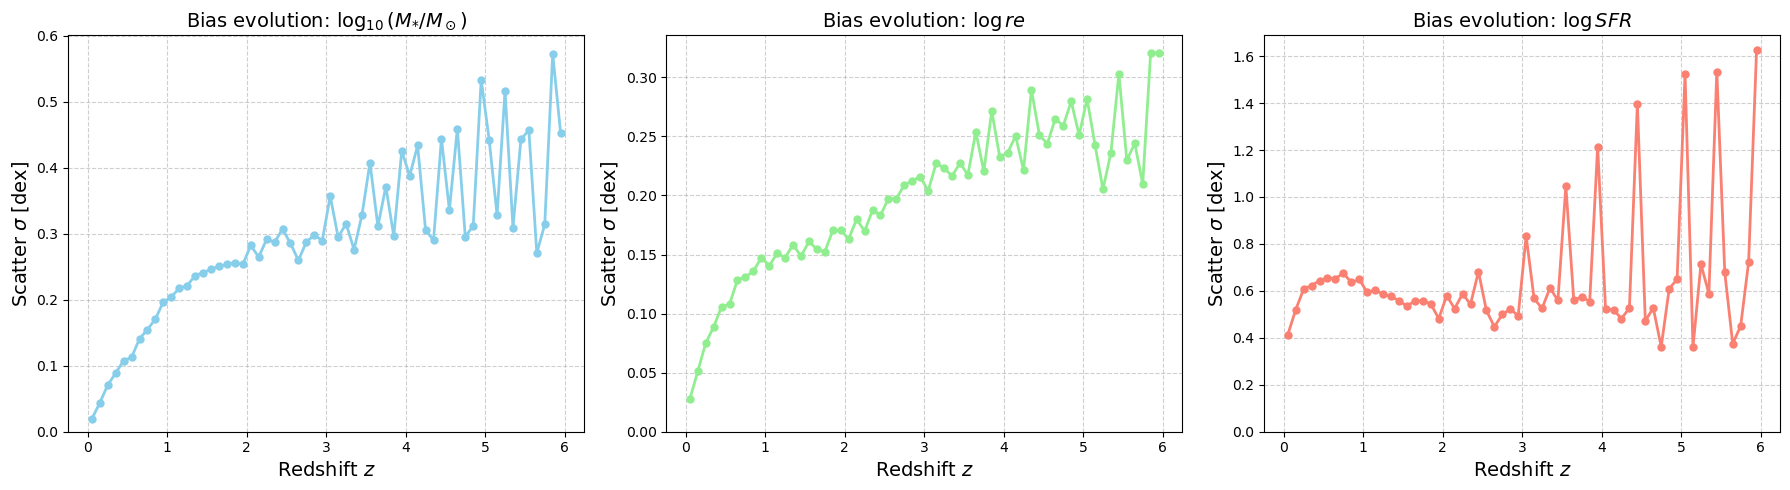

In [55]:
# Plot sigma evolution
props_names = [r'$\log_{10}(M_\mathrm{*} / M_\odot)$', r'$\log re$', r'$\log SFR$']
colors = ['skyblue', 'lightgreen', 'salmon']


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col in range(3):
    ax = axes[col]
    
    # X axis: Redshifts, Y axis: Sigma
    ax.plot(bin_centers, sigma_evolution[:, col], 
            color=colors[col], marker='o', 
            linewidth=2, markersize=5, label=r'Scatter ($\sigma$)')

    # Decorate plot
    ax.set_title(f'Bias evolution: {props_names[col]}', fontsize=14)
    ax.set_xlabel('Redshift $z$', fontsize=14)
    ax.set_ylabel(r'Scatter $\sigma$ [dex]', fontsize=14)

    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_ylim(bottom=0)

fig.tight_layout()

final_file_path = os.path.join(full_dir_path, 'bias_evolution.png')
plt.savefig(final_file_path, bbox_inches='tight', dpi=500)
plt.show()



Plot `mu_evolution` and `sigma_evolution`

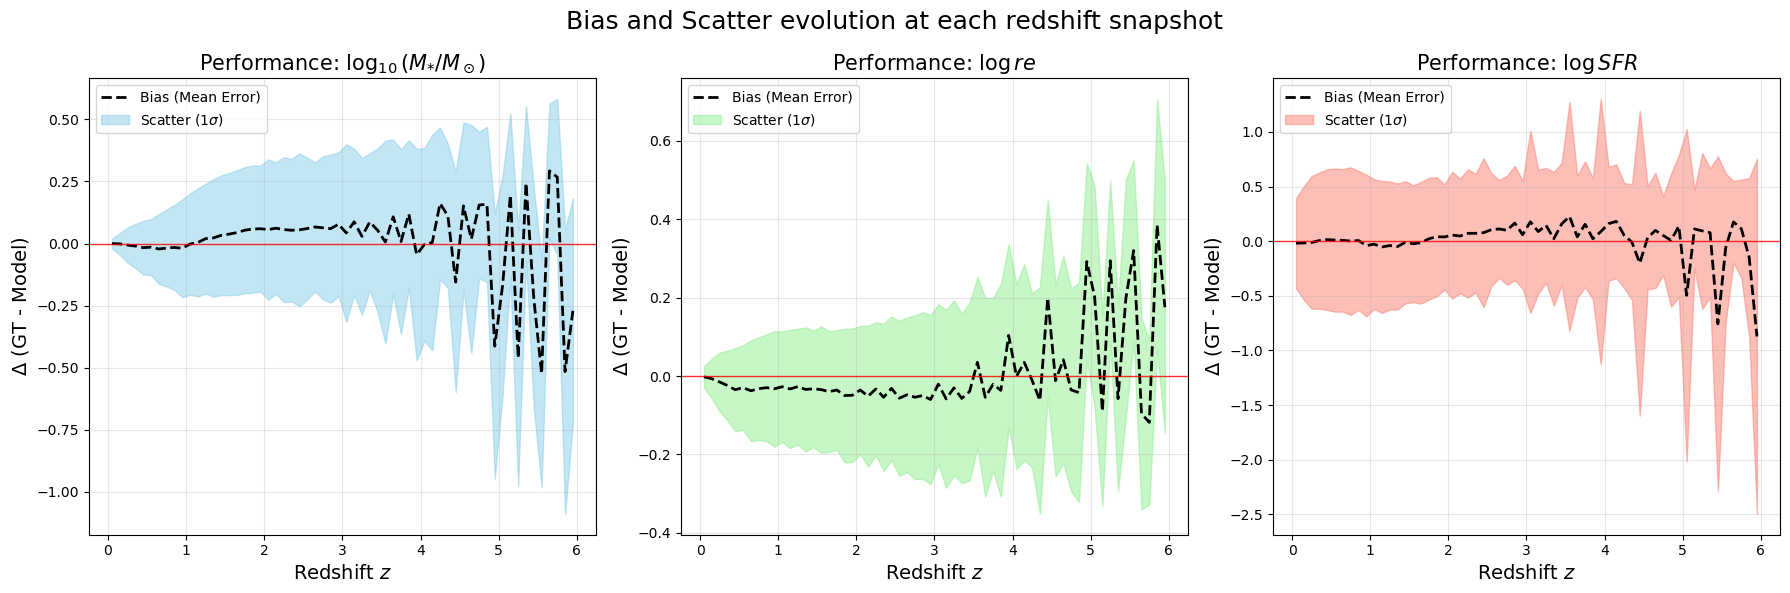

In [56]:
# Plot mu evolution 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for col in range(3):
    ax = axes[col]
    
    # A. Plot mu (bias)
    ax.plot(bin_centers, mu_evolution[:, col], 
            color='k', linestyle='--', linewidth=2, label='Bias (Mean Error)')
    
    # B. Plot scatter with fill_between
    # Filling between (Mean - Sigma) y (Mean + Sigma)
    lower_bound = mu_evolution[:, col] - sigma_evolution[:, col]
    upper_bound = mu_evolution[:, col] + sigma_evolution[:, col]
    
    ax.fill_between(bin_centers, lower_bound, upper_bound, 
                    color=colors[col], alpha=0.5, label=r'Scatter ($1\sigma$)')
    
    # Plot reference at mu = 0
    ax.axhline(0, color='red', linewidth=1, alpha=0.8)
    
    # Decorate
    ax.set_title(f'Performance: {props_names[col]}', fontsize=15)
    ax.set_xlabel('Redshift $z$', fontsize=14)
    ax.set_ylabel(r'$\Delta$ (GT - Model)', fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

fig.suptitle('Bias and Scatter evolution at each redshift snapshot', fontsize=18)
fig.tight_layout()
final_file_path = os.path.join(full_dir_path, 'mu_evol_with_scatter.png')
plt.savefig(final_file_path, bbox_inches='tight', dpi=500)
plt.show()


### How good is our error estimation?

We will now study how good is our error estimation for a galaxy that we don't know its ground truth.

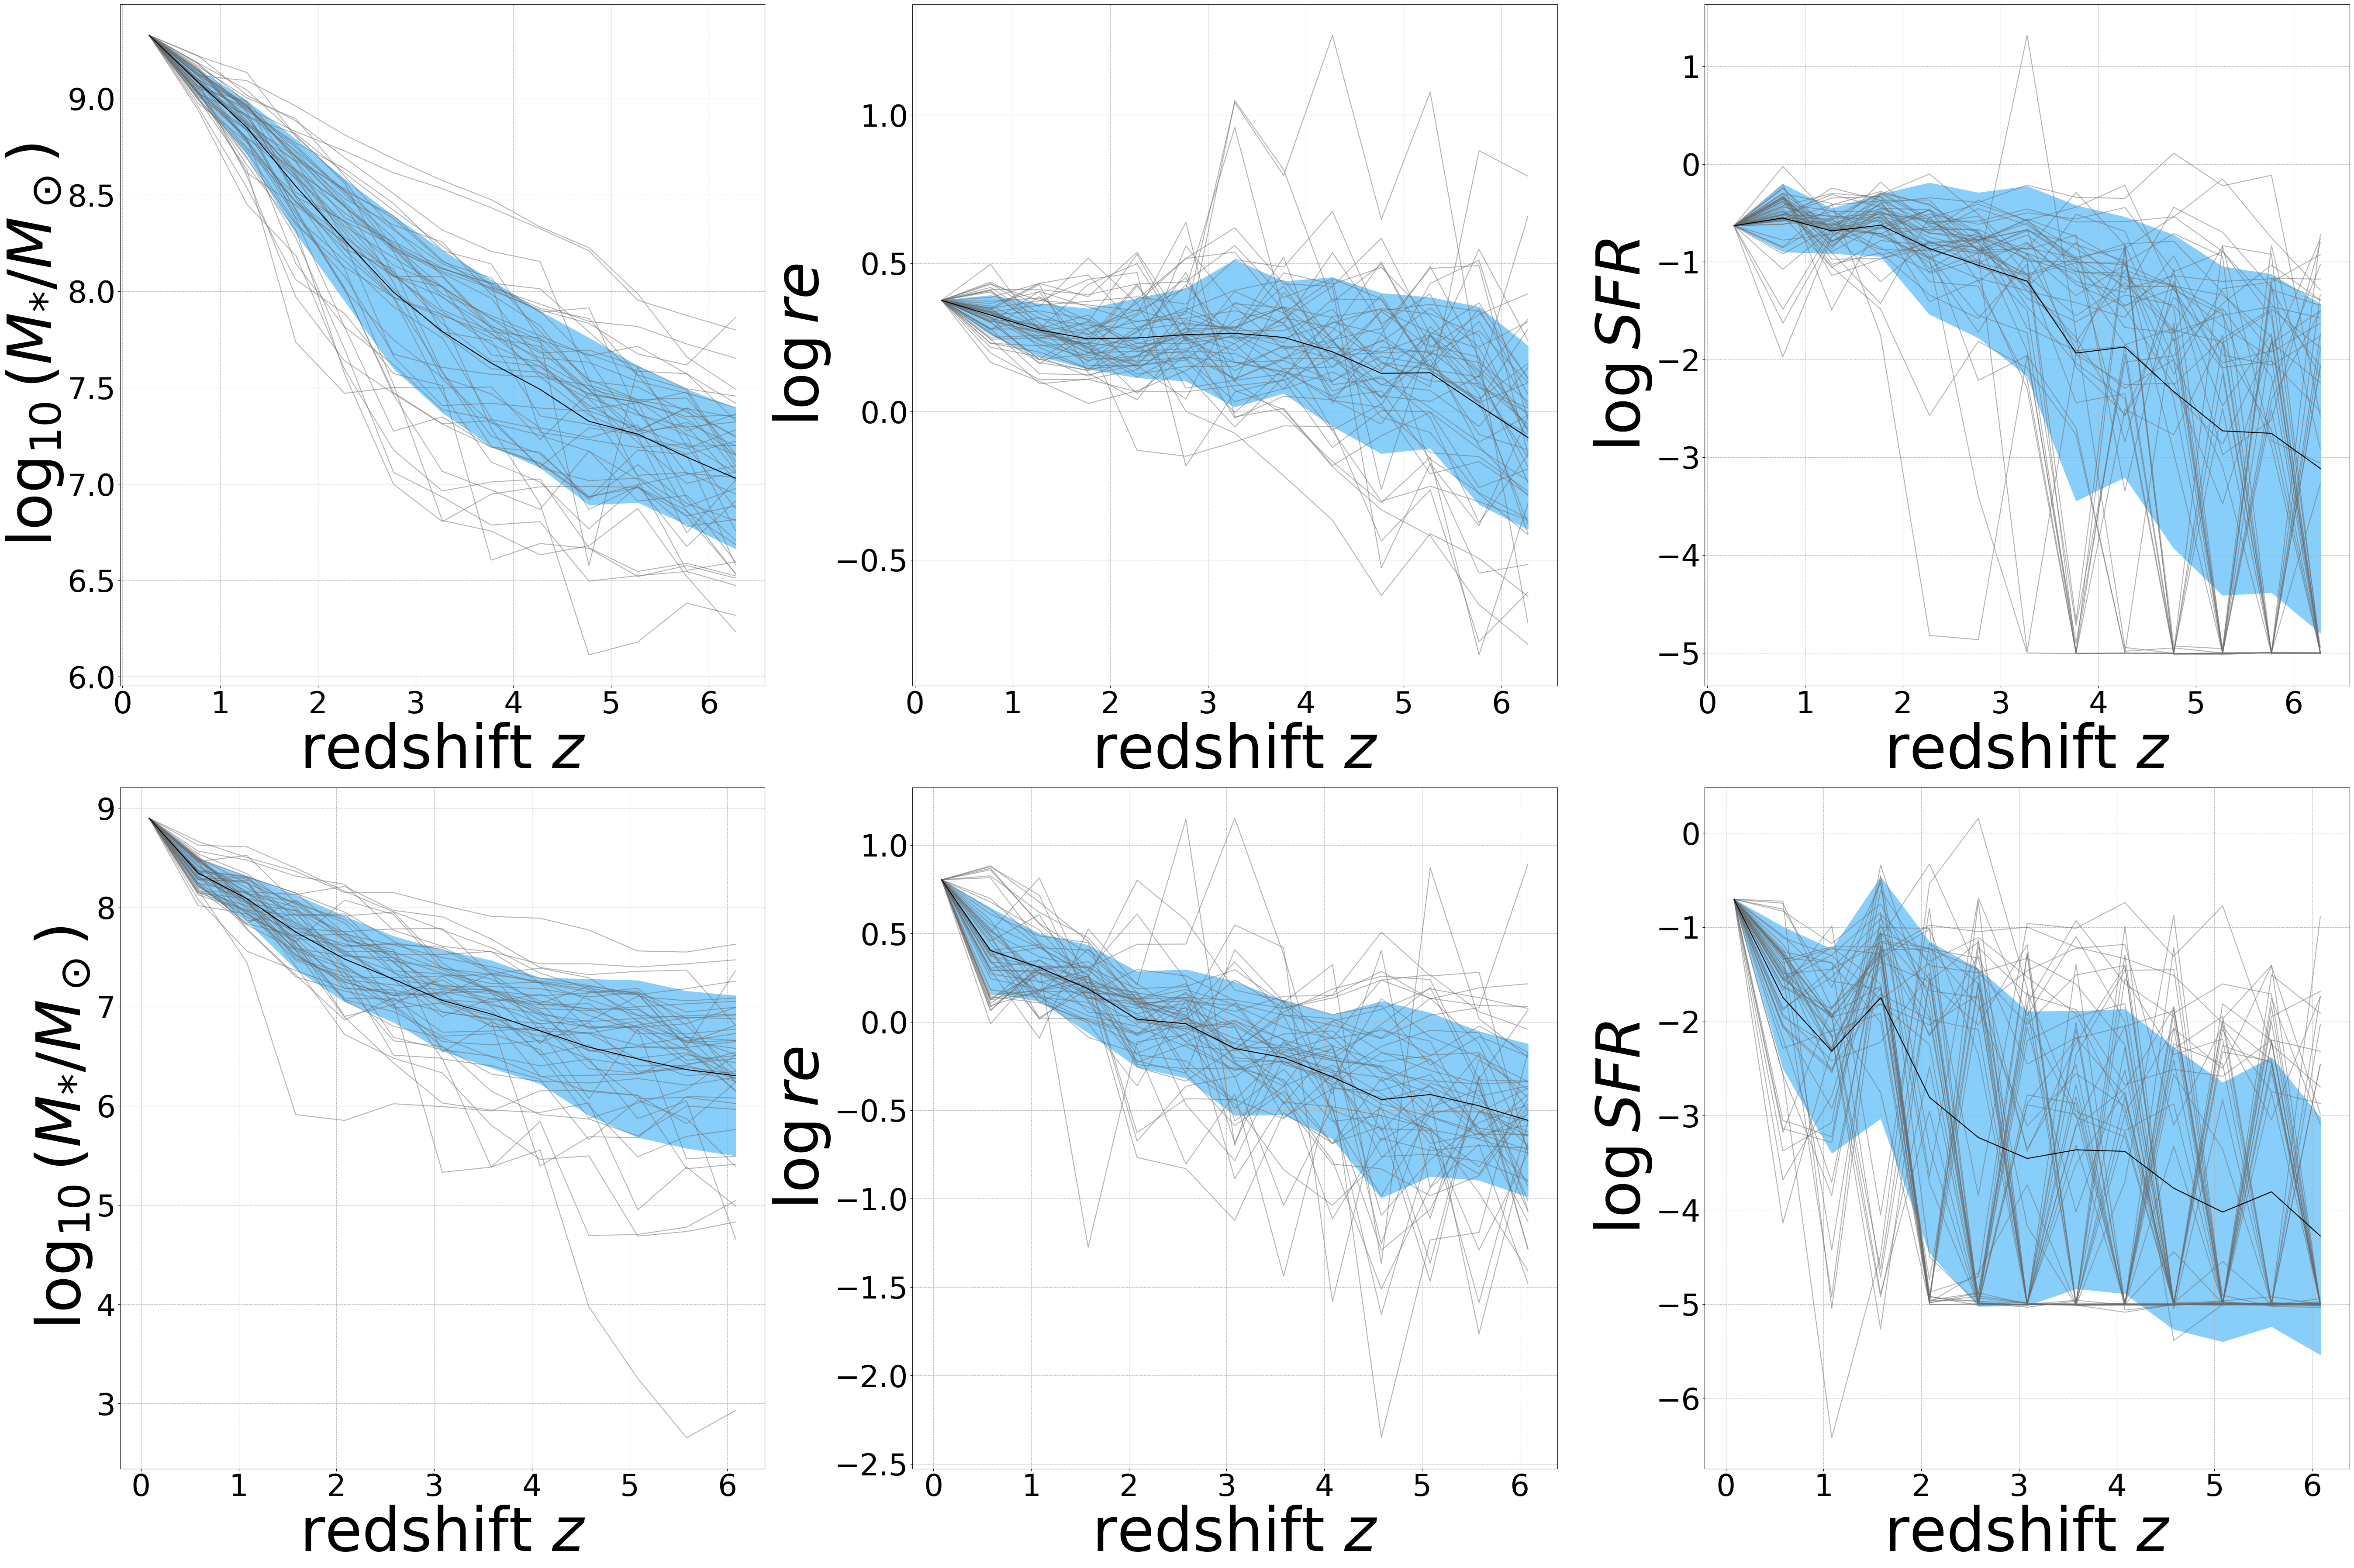

In [39]:
# Number of elements to plot from x_val
num_elements = 2
start_index = 460

# Create a grid of plots (num_elements rows, 3 columns)
fig, axes = plt.subplots(num_elements, 3, figsize=(18*3, 18*num_elements))

means_list = []
std_list = []


# Iterate over the elements of x_val and create subplots
for i,pos in enumerate(range(start_index,start_index+num_elements)):
    # Now we can sample the trees for the current element of x_val
    n_trees = 50
    root = x_val_tng[pos][0]
    roots = np.tile(root, (n_trees, 1))

    z_init = (1 / t_val_tng[pos] - 1 )[0].item()
    z_init = min(z_init, 6)  # Ensure starting value does not exceed 6ç
    
    # Create the redshifts array
    redshifts = np.arange(z_init, 6.5, 0.5)  # 6.5 as the stop value ensures inclusion of 6 if it's within the step range

    scale_factors = 1 / (1 + redshifts)
    scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
    scale_factors = scale_factors[..., np.newaxis]

    # Sample the trees for the current element of x_val
    sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)
    means_trees = np.mean(sampled_trees, axis=0) # Mean model prediction on the grid.
    std_trees = np.std(sampled_trees, axis=0)

    means_list.extend(means_trees)
    std_list.extend(std_trees)


    # Plot the MAH and CAH of the i-th element of x_val
    for j in range(n_trees):
        z = 1 / scale_factors[j] - 1  # redshift
        axes[i, 0].plot(z, sampled_trees[j][:, 0], c='dimgray', alpha=0.5)
        axes[i, 1].plot(z, sampled_trees[j][:, 1], c='dimgray', alpha=0.5)
        axes[i, 2].plot(z, sampled_trees[j][:, 2], c='dimgray', alpha=0.5)
        
        #axes[i, 2].plot(sampled_trees[j][:, 0], sampled_trees[j][:, 1], c='k', alpha=0.5)

    z = 1 / scale_factors[0] - 1
    z = z.flatten()
    axes[i, 0].plot(z, means_trees[:, 0], color='k')
    axes[i, 1].plot(z, means_trees[:, 1], color='k')
    axes[i, 2].plot(z, means_trees[:, 2], color='k')

    axes[i, 0].fill_between(z, means_trees[:, 0] - std_trees[:,0], means_trees[:, 0] + std_trees[:,0], color='lightskyblue')
    axes[i, 1].fill_between(z, means_trees[:, 1] - std_trees[:,1], means_trees[:, 1] + std_trees[:,1], color='lightskyblue' )
    axes[i, 2].fill_between(z, means_trees[:, 2] - std_trees[:,2], means_trees[:, 2] + std_trees[:,2], color='lightskyblue')



    # Set axis labels and tick label size
    axes[i, 0].set_ylabel(r'$\log_{10}(M_\mathrm{*} / M_\odot)$', fontsize=100)
    axes[i, 1].set_ylabel(r'$\log re$', fontsize=100)
    axes[i, 0].set_xlabel(r'redshift $z$', fontsize=100)
    axes[i, 1].set_xlabel(r'redshift $z$', fontsize=100)
    axes[i, 2].set_xlabel(r'redshift $z$', fontsize=100)
    #axes[i, 2].set_xlabel(r'$\log_{10}(M_\mathrm{*} / M_\odot)$', fontsize=100)
    axes[i, 2].set_ylabel(r'$\log SFR$', fontsize=100)
    # Increase the size of tick labels
    for ax in axes[i, :]:
        ax.tick_params(axis='both', labelsize=50)
        ax.grid(True, which='major', linestyle='--', alpha=0.9)




# Tight layout for better spacing
fig.tight_layout()


# Show the plot
plt.show()


Doing the same but for more galaxies

In [40]:
# Number of elements to plot from x_val
num_elements = 100
start_index = 3

z_list = []
means_list = []
std_list = []
delta_list = []


# Iterate over the elements of x_val and create subplots
for i,pos in enumerate(range(start_index,start_index+num_elements)):
    # Now we can sample the trees for the current element of x_val
    n_trees = 50
    root = x_val[pos][0]
    roots = np.tile(root, (n_trees, 1))

    z_init = (1 / t_val[pos] - 1 )[0].item()
    z_init = min(z_init, 6)  # Ensure starting value does not exceed 6ç
    
    # Create the redshifts array
    redshifts = np.arange(z_init, 6.5, 0.5)  # 6.5 as the stop value ensures inclusion of 6 if it's within the step range

    scale_factors = 1 / (1 + redshifts)
    scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
    scale_factors = scale_factors[..., np.newaxis]

    # Sample the trees for the current element of x_val
    sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)
    means_trees = np.mean(sampled_trees, axis=0) # Mean model prediction on the grid.
    std_trees = np.std(sampled_trees, axis=0)

    # Calculate delta = 2*std at each redshift
    delta = 2 * std_trees

    # Store each value
    z_list.extend(redshifts)
    means_list.extend(means_trees)
    std_list.extend(std_trees)
    delta_list.extend(delta)

# We convert to np.array in order to compute means later
all_z = np.array(z_list)                         # Shape: (N,)
all_means = np.array(means_list)                 # Not really needed from now on
all_std = np.array(std_list)                     # Not really needed from now on
all_delta = np.array(delta_list)                 # Shape: (N, 3)

In [41]:
# WIP: Plot evolution of error !!
# 
#  --- Statistical binning ---
# Define bins where we want to evaluate the errors
z_bins = np.arange(0, 6.5, 0.1) # Adjust to your liking, the more points the better
bin_centers = []
mu_evolution = []
sigma_evolution = []

for i in range(len(z_bins) - 1):
    z_min = z_bins[i]
    z_max = z_bins[i+1]
    
    # Mask: We only take galaxies included in the bin. 
    mask = (all_z >= z_min) & (all_z < z_max)
    
    if np.any(mask): 
        diffs_in_bin = all_delta[mask] # Select only the data that fall in this bin
        
        # Calculate mean and standar deviation in each column (axis=0)
        mean_in_bin = np.mean(diffs_in_bin, axis=0)
        std_in_bin = np.std(diffs_in_bin, axis=0)
        
        mu_evolution.append(mean_in_bin)
        sigma_evolution.append(std_in_bin)
        bin_centers.append((z_min + z_max) / 2)
    else:
        # Optional: Fill with NaNs if bin is empty, in order to not break graphs (ideal is num_elements is low)
        mu_evolution.append([np.nan, np.nan, np.nan])
        sigma_evolution.append([np.nan, np.nan, np.nan])
        bin_centers.append((z_min + z_max) / 2)

# We convert to np.array in order to compute means later
mu_evolution = np.array(mu_evolution)       # Shape: (N_bins, 3)
sigma_evolution = np.array(sigma_evolution) # Shape: (N_bins, 3)
bin_centers = np.array(bin_centers)

print("mu_evolution shape:", mu_evolution.shape)
print("z_bins and bin_centers shape:", z_bins.shape, bin_centers.shape)

mu_evolution shape: (64, 3)
z_bins and bin_centers shape: (65,) (64,)


Bin z~0.450: 10 galaxies found.
Bin z~1.450: 19 galaxies found.
Bin z~2.950: 21 galaxies found.
Bin z~4.450: 21 galaxies found.


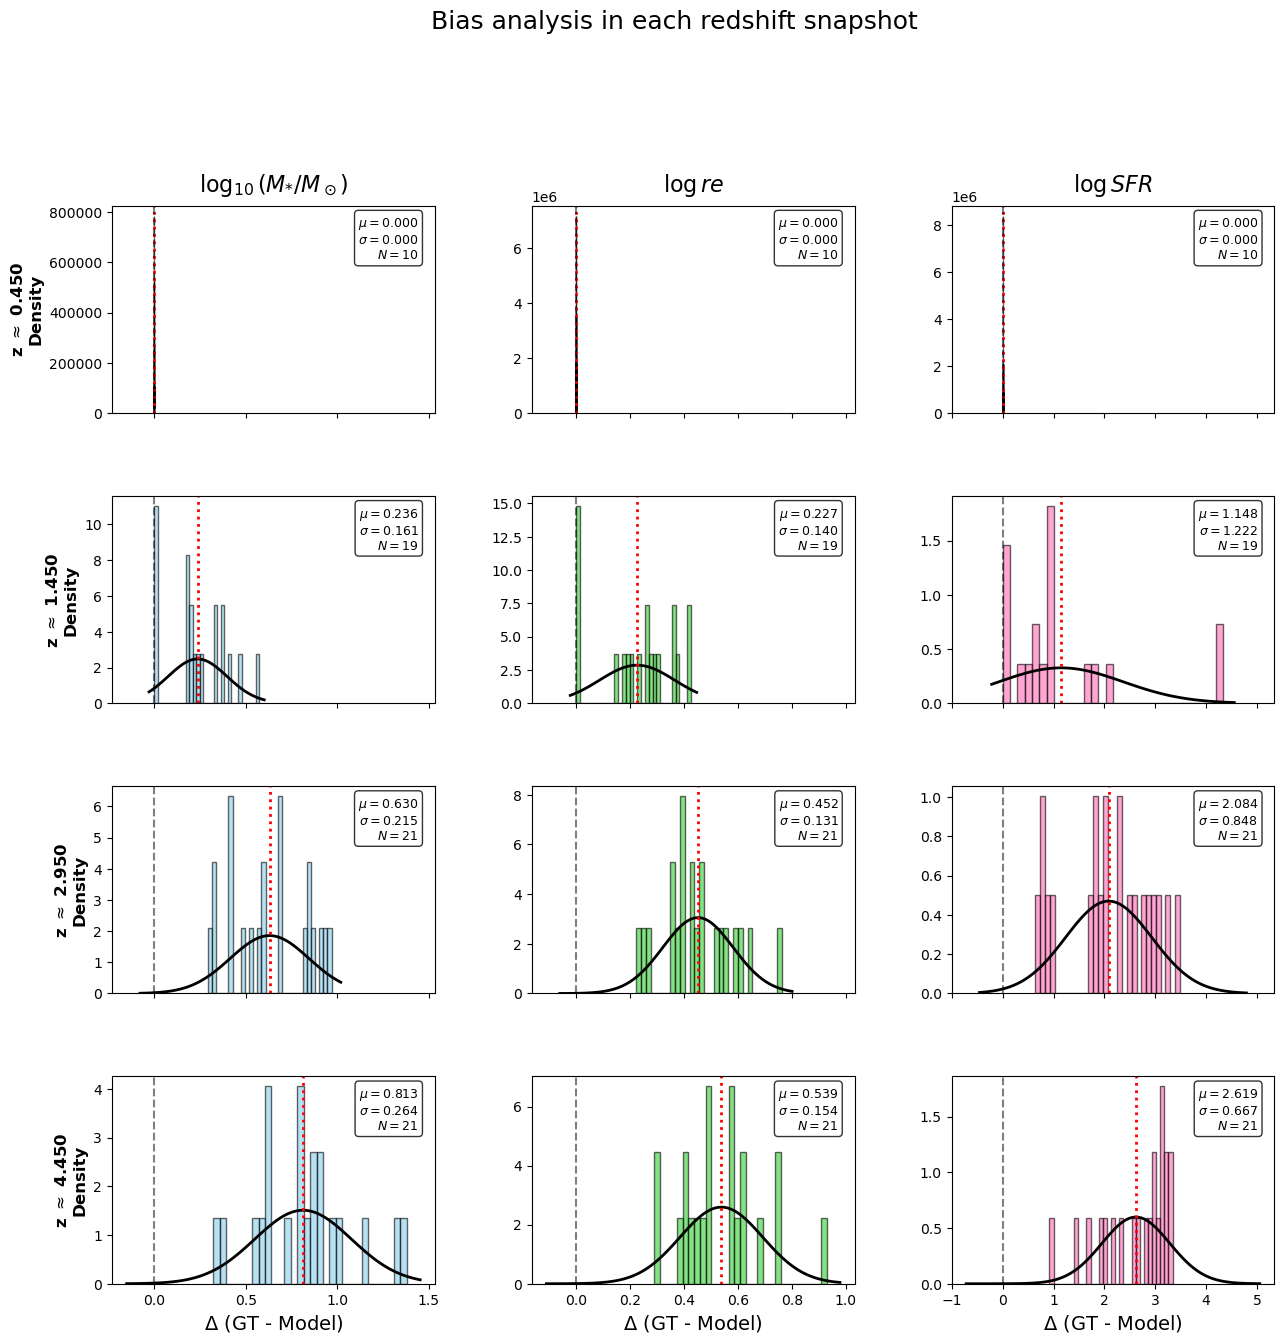

In [42]:
# --- 1. Snapshot configuration ---
# Choose in this array which redshifts you'd like to plot, they will be searched for in bin_centers
zs_targets = [0.5, 1.5, 3.0, 4.5] 


# Labels for the plots
props_names = [r'$\log_{10}(M_\mathrm{*} / M_\odot)$', r'$\log re$', r'$\log SFR$']
colors = ['skyblue', 'limegreen', 'hotpink']

# Search for index of those bins closer to the targets 
indices_to_plot = []
for z_t in zs_targets:
    idx = (np.abs(bin_centers - z_t)).argmin()
    if idx not in indices_to_plot:
        indices_to_plot.append(idx)

# --- 2. Plot configuration ---
# squeeze=False makes sure that axes_hist will always be 2D matrix [filas, cols]
# even if zs_target has 1 redshift.
n_rows = len(indices_to_plot)
fig_hist, axes_hist = plt.subplots(n_rows, 3, figsize=(15, 3.5 * n_rows), 
                                   sharex='col', squeeze=False)
plt.subplots_adjust(hspace=0.4, wspace=0.3)


for row_idx, bin_idx in enumerate(indices_to_plot):
    z_center = bin_centers[bin_idx]
    z_min = z_bins[bin_idx]
    z_max = z_bins[bin_idx+1]

    # We use mask to filter only data that fall in this bin
    mask = (all_z >= z_min) & (all_z < z_max)
    data_in_bin = all_delta[mask]
    n_samples = len(data_in_bin)
    
    # Warns if there is an empty bin (may happen if num_elements is low)
    if n_samples == 0:
        print(f"WARNING: bin centered in z={z_center:.3f} is EMPTY. Skipping plot.")
    else:
        print(f"Bin z~{z_center:.3f}: {n_samples} galaxies found.")

    for col in range(3):
        ax = axes_hist[row_idx, col]
        
        mu = mu_evolution[bin_idx, col]
        sigma = sigma_evolution[bin_idx, col]
        
        # If there is no data, we plot just that
        if n_samples < 2 or np.isnan(mu):
            ax.text(0.5, 0.5, "NO DATA / NAN", transform=ax.transAxes, 
                    ha='center', va='center', color='red', fontsize=12)
            if col == 0: ax.set_ylabel(f"z $\\approx$ {z_center:.3f}", fontweight='bold', fontsize=12)
            continue

        # --- HISTOGRAM ---
        # density=True normalizes to 1 so that we can compare to a gaussian later
        vals = data_in_bin[:, col]
        n, bins_hist, patches = ax.hist(vals, bins=30, color=colors[col], 
                                        edgecolor='black', alpha=0.6, density=True, label='Data')

        # We plot a gaussian with the same values of mu and sigma, so that we can check if our 
        # distribution matches with it
        xmin, xmax = ax.get_xlim()
        # We add a small margin if the data range is very narrow.
        if xmin == xmax: 
            xmin -= 0.1; xmax += 0.1
            
        x_plot = np.linspace(xmin, xmax, 100)
        
        if sigma > 0:
            y_plot = norm.pdf(x_plot, loc=mu, scale=sigma)
            ax.plot(x_plot, y_plot, 'k-', lw=2, label='Fit (Global)')
            ax.axvline(mu, color='r', linestyle=':', linewidth=2) 
            ax.axvline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.5) 


        # --- Decorate ---
        if row_idx == 0:
            ax.set_title(props_names[col], fontsize=16, pad=10)
            
        if col == 0:
            # Laber indicatind redshift of the bin
            ax.set_ylabel(f"z $\\approx$ {z_center:.3f}\nDensity", fontsize=12, fontweight='bold')

        # Show statistics (mean, sigma and n_samples in each bin)
        stats_text = f'$\\mu={mu:.3f}$\n$\\sigma={sigma:.3f}$\n$N={n_samples}$'
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=9, va='top', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# X axis labels at the bottom
for col in range(3):
    axes_hist[-1, col].set_xlabel(r'$\Delta$ (GT - Model)', fontsize=14)

fig_hist.suptitle(f"Bias analysis in each redshift snapshot", fontsize=18, y=1.02)
#final_file_path = os.path.join(full_dir_path, 'histograms.png')
#plt.savefig(final_file_path, bbox_inches='tight', dpi=500)
plt.show()

### Other things:

In [ ]:
pos = 552
x_values = np.array(x_val[pos][:, 2]).astype('float')  # your x data, corresponding to z
mass =np.array(x_val[pos][:, 0]).astype('float')  
sfr = 10**x_values
z = 1 / t_val[pos] - 1 # redshift
z= z.flatten()

mass_today = np.array(x_val[pos][0, 0])
mass_start = np.array(x_val[pos][len(z)-1, 0])

# Use Planck13 cosmology
cosmo = Planck13
lookback_time = cosmo.lookback_time(z).to(u.Gyr).value  # Convert to Gyr

sort_indices = np.argsort(lookback_time)
time_sorted = lookback_time[sort_indices]
sfr_sorted = sfr[sort_indices]
mass_sorted = mass[sort_indices]

# Calculate the differences in time between each point to get delta time in Gyr
delta_time = np.diff(time_sorted)  # Time intervals between each point

stellar_mass = np.sum(sfr_sorted[:-1] * delta_time * 1e9) 

# Plot the data
plt.figure()
plt.plot(time_sorted, sfr_sorted)
plt.xlabel('time')
plt.ylabel('SFR')
plt.title('Plot of x values vs. z')
plt.show()

plt.figure()
plt.plot(time_sorted, mass_sorted)
plt.xlabel('time')
plt.ylabel('Mass')
plt.title('Plot of x values vs. z')
plt.show()

#print(time_sorted)



#total_integral = integrate.trapz(sfr, z)
print(f'Total integral: {np.log10(stellar_mass)}')
print(f'Total mass from SFR: {np.log10(stellar_mass+10**mass_start)}')

# Define bins for z
z_bins = np.linspace(z.min(), z.max(), num=5)  # Replace 'num' with your desired number of bins

# Compute integral within each bin
bin_integrals = []
for i in range(len(z_bins)-1):
    # Find indices of z that fall into the current bin
    indices = np.where((z >= z_bins[i]) & (z < z_bins[i+1]))[0]
    
    # Compute integral for this bin using the trapezoidal rule
    if indices.size > 1:  # Need at least two points to compute an integral
        bin_integral = np.trapezoid(sfr[indices], z[indices] )
        bin_integrals.append(bin_integral)
    else:
        bin_integrals.append(0)  # No data in this bin

# Print the integral for each bin
for i, integral in enumerate(bin_integrals):
    print(f'Integral for bin {i} ({z_bins[i]}, {z_bins[i+1]}): {integral}')

In [ ]:
# Example setup, replace with your actual data and starting position
pos_start = 0  # Starting position, replace with your actual starting position
n_positions = 100  # Number of positions to process

# Arrays to store final results for plotting
log_mass_today_array = []
log_stellar_mass_array = []

# Loop over the positions
for pos in range(pos_start, pos_start + n_positions):
    # Your data extraction and calculations here:
    x_values = np.array(x_val[pos][:, 2]).astype('float')  # SFR data
    # mass = np.array(x_val[pos][:, 0]).astype('float')  # Mass data
    sfr = 10**x_values
    z = 1 / t_val[pos] - 1  # Redshift
    z = z.flatten()

    mass_today = np.array(x_val[pos][0, 0])
    mass_start = np.array(x_val[pos][-1, 0])

    # Use Planck13 cosmology
    cosmo = Planck13
    lookback_time = cosmo.lookback_time(z).to(u.Gyr).value  # Convert to Gyr

    sort_indices = np.argsort(lookback_time)
    time_sorted = lookback_time[sort_indices]
    sfr_sorted = sfr[sort_indices]

    # Calculate the differences in time between each point to get delta time in Gyr
    delta_time = np.diff(time_sorted)  # Time intervals between each point

    # Calculate stellar mass formed between each time interval
    stellar_mass = np.sum(sfr_sorted[:-1] * delta_time * 1e9)  # Convert SFR from per year to per Gyr

    # Store results for final plot
    log_mass_today_array.append(mass_today)
    log_stellar_mass_array.append(np.log10(stellar_mass + 10**mass_start))

# After processing all positions, plot the results
plt.figure()
plt.scatter(log_mass_today_array, log_stellar_mass_array)
plt.xlabel('log(Mass Today) [log(Solar Mass)]')
plt.ylabel('log(Total Mass from SFH) [log(Solar Mass)]')
plt.title('Log(Mass Today) vs. Log(Total Mass from SFR)')
plt.grid(True)
plt.plot(np.linspace(6,12),np.linspace(6,12),color='red',lw=3)
plt.xlim(8.12)
plt.ylim(8.12)
plt.show()


In [ ]:
pos_start=0
n_positions = 100
# Arrays to store final results for plotting
log_mass_today_array = []
log_stellar_mass_array = []


for i,pos in enumerate(range(pos_start,pos_start+n_positions)):
    # Now we can sample the trees for the current element of x_val
    n_trees = 1
    root = x_val[pos][0]
    roots = np.tile(root, (n_trees, 1))

    redshifts = np.array([0,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,6])
    scale_factors = 1 / (1 + redshifts)
    scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
    scale_factors = scale_factors[..., np.newaxis]

    # Sample the trees for the current element of x_val
    sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors) # duda: por qué saca solo 1 array? -> Porque hemos puesto n_trees =1
    x_values = np.array(sampled_trees[0][:, 2]).astype('float')  # SFR data
    mass = np.array(sampled_trees[0][:, 0]).astype('float')  # Mass data
    sfr = 10**x_values
    z = 1 / scale_factors[0] - 1  # redshift
    z = z.flatten()
    mass_today = np.array(sampled_trees[0][0, 0])
    mass_start = np.array(sampled_trees[0][-1, 0])

    # Use Planck13 cosmology
    cosmo = Planck13
    lookback_time = cosmo.lookback_time(z).to(u.Gyr).value  # Convert to Gyr

    sort_indices = np.argsort(lookback_time)
    time_sorted = lookback_time[sort_indices]
    sfr_sorted = sfr[sort_indices]

    # Calculate the differences in time between each point to get delta time in Gyr
    delta_time = np.diff(time_sorted)  # Time intervals between each point

    # Calculate stellar mass formed between each time interval
    stellar_mass = np.sum(sfr_sorted[:-1] * delta_time * 1e9)  # Convert SFR from per year to per Gyr

    # Store results for final plot
    log_mass_today_array.append(mass_today)
    log_stellar_mass_array.append(np.log10(stellar_mass + 10**mass_start))

# After processing all positions, plot the results
plt.figure()
plt.scatter(log_mass_today_array, log_stellar_mass_array)
plt.xlabel('log(Mass Today) [log(Solar Mass)]')
plt.ylabel('log(Total Mass from SFH) [log(Solar Mass)]')
plt.title('Log(Mass Today) vs. Log(Total Mass from SFR)')
plt.plot(np.linspace(6,12),np.linspace(6,12),color='red',lw=3)
plt.xlim(8.12)
plt.ylim(8.12)
plt.grid(True)
plt.show()

    
    
                                                
                                                
                                                
                                                
        
     

In [ ]:
# Define the simulation and redshift you're interested in
sim_name = 'EAGLE'  # Replace with your simulation name
z_value = 0.5  # Replace with your redshift value

# Path to your HDF5 file
data_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\"
hdf5_file_path = data_path+"all_simulations_data.hdf5"


# Construct the group name from the simulation name and redshift
group_name = f"{sim_name}/z{z_value:.2f}"  # e.g., "Illustris1/z0.50"

# Open the HDF5 file and read the data
with h5py.File(hdf5_file_path, 'r') as hdf5_file:
    # Check if the group exists
    if group_name in hdf5_file:
        # Read the mass and SFR data
        mass = hdf5_file[group_name]['Subhalos']['Mass'][:]
        sfr = hdf5_file[group_name]['Subhalos']['SFR'][:]
        
        # Filter out any invalid values (e.g., inf, -inf, NaN)
        valid_indices = (np.isfinite(mass) & np.isfinite(sfr) & (sfr > 0))
        mass = mass[valid_indices]
        sfr = sfr[valid_indices]
        
        # Plot mass vs. SFR
        plt.figure(figsize=(10, 6))
        plt.scatter(mass, sfr, alpha=0.5,s=1,color='black')
        plt.xlabel('Log Mass [log(Solar Mass)]')
        plt.ylabel('Log SFR [log(Solar Mass/Year)]')
        plt.title(f'Mass vs. SFR for {sim_name} at z={z_value}')
        plt.grid(True)
        plt.show()
    else:
        print(f"Data for {group_name} not found in the file.")


In [ ]:
# Define the redshift you're interested in
z_value = 2  # Replace with your redshift value

# Path to your HDF5 file
data_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\"
hdf5_file_path = data_path+"all_simulations_data.hdf5"


# List of simulations to compare
sim_names = ['EAGLE', 'Simba', 'TNG']  # Replace with your actual simulation names

# Number of mass bins
n_bins = 20  # You can adjust this

# Set up the plot
plt.figure(figsize=(10, 6))

# Loop over each simulation
for sim_name in sim_names:
    group_name = f"{sim_name}/z{z_value:.2f}"  # Construct the group name

    # Open the HDF5 file and read the data
    with h5py.File(hdf5_file_path, 'r') as hdf5_file:
        # Check if the group exists
        if group_name in hdf5_file:
            # Read the mass and SFR data
            mass = hdf5_file[group_name]['Subhalos']['Mass'][:]
            sfr = hdf5_file[group_name]['Subhalos']['SFR'][:]
            
            # Filter out any invalid values
            valid_indices = (np.isfinite(mass) & np.isfinite(sfr))
            mass = mass[valid_indices]
            sfr = sfr[valid_indices]

            # Bin the data
            bins = np.linspace(mass.min(), mass.max(), n_bins+1)
            digitized = np.digitize(mass, bins)
            bin_centers = 0.5 * (bins[:-1] + bins[1:])

            # Calculate average SFR for each bin
            bin_means = [sfr[digitized == i].mean() for i in range(1, len(bins))]

            # Plot
            plt.plot(bin_centers, bin_means, label=f'{sim_name}', marker='o')

        else:
            print(f"Data for {group_name} not found in the file.")

# Customize and show plot
plt.xlabel('Log Mass [log(Solar Mass)]')
plt.ylabel('Average Log SFR [log(Solar Mass/Year)]')
plt.title(f'Running Average SFR in Bins of Mstar for z={z_value}')
plt.legend()
plt.grid(True)
pos_start=0
n_positions = 100
# Arrays to store final results for plotting
log_sfr_array = []
log_stellar_mass_array = []

pos_start=0
n_positions = 150
for i,pos in enumerate(range(pos_start,pos_start+n_positions)):
    # Now we can sample the trees for the current element of x_val
    n_trees = 1
    root = x_val[pos][0]
    roots = np.tile(root, (n_trees, 1))

    redshifts = np.array([0,0.5,1,1.5,2])
    scale_factors = 1 / (1 + redshifts)
    scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
    scale_factors = scale_factors[..., np.newaxis]

    # Sample the trees for the current element of x_val
    sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)
    x_values = np.array(sampled_trees[0][4, 2]).astype('float')  # SFR data. Index 4 takes into account z=2
    mass = np.array(sampled_trees[0][4, 0]).astype('float')  # Mass data
    #sfr = 1x_values
    z = 1 / scale_factors[0] - 1  # redshift
    z = z.flatten()
    

    # Store results for final plot
    log_sfr_array.append(x_values)
    log_stellar_mass_array.append(mass)

log_sfr_array=np.array(log_sfr_array)
log_stellar_mass_array = np.array(log_stellar_mass_array)
# After processing all positions, plot the results
# Bin the data
bins = np.linspace(log_stellar_mass_array.min(), log_stellar_mass_array.max(), n_bins+1)
digitized = np.digitize(log_stellar_mass_array, bins)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Calculate average SFR for each bin
bin_means = [log_sfr_array[digitized == i].mean() for i in range(1, len(bins))]

# Plot
plt.plot(bin_centers, bin_means, color='hotpink',label='samples', marker='o')
plt.scatter(log_stellar_mass_array, log_sfr_array,color='hotpink',s=4)
#plt.xlabel('log(Mass Today) [log(Solar Mass)]')
#plt.ylabel('log(Total Mass from SFR) [log(Solar Mass)]')
#plt.title('Log(Mass Today) vs. Log(Total Mass from SFR)')
#plt.plot(np.linspace(6,12),np.linspace(6,12),color='red',lw=3)
#plt.xlim(8.12)
#plt.ylim(8.12)
#plt.grid(True)
plt.legend()


plt.show()


In [ ]:
# Define the redshift you're interested in
z_value = 4  # Replace with your redshift value

# Path to your HDF5 file
data_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\"
hdf5_file_path = data_path+"all_simulations_data.hdf5"

# List of simulations to compare
sim_names = ['EAGLE', 'Simba', 'TNG']  # Replace with your actual simulation names

# Number of mass bins
n_bins = 20  # You can adjust this

# Set up the plot
plt.figure(figsize=(10, 6))

# Loop over each simulation
for sim_name in sim_names:
    group_name = f"{sim_name}/z{z_value:.2f}"  # Construct the group name

    # Open the HDF5 file and read the data
    with h5py.File(hdf5_file_path, 'r') as hdf5_file:
        # Check if the group exists
        if group_name in hdf5_file:
            # Read the mass and SFR data
            mass = hdf5_file[group_name]['Subhalos']['Mass'][:]
            sfr = hdf5_file[group_name]['Subhalos']['Re'][:]
            sfr = np.log10(10**sfr/0.704**2) # correction of bug
            # Filter out any invalid values
            valid_indices = (np.isfinite(mass) & np.isfinite(sfr))
            mass = mass[valid_indices]
            sfr = sfr[valid_indices]

            # Bin the data
            bins = np.linspace(mass.min(), mass.max(), n_bins+1)
            digitized = np.digitize(mass, bins)
            bin_centers = 0.5 * (bins[:-1] + bins[1:])

            # Calculate average SFR for each bin
            bin_means = [sfr[digitized == i].mean() for i in range(1, len(bins))]

            # Plot
            plt.plot(bin_centers, bin_means, label=f'{sim_name}', marker='o')

        else:
            print(f"Data for {group_name} not found in the file.")

# Customize and show plot
plt.xlabel('Log Mass [log(Solar Mass)]')
plt.ylabel('Average Log Re [log(Solar Mass/Year)]')
plt.title(f'Running Average Re in Bins of Mstar for z={z_value}')
plt.legend()
plt.grid(True)
pos_start=55000
n_positions = 100
# Arrays to store final results for plotting
log_sfr_array = []
log_stellar_mass_array = []

pos_start=0
n_positions = 400
for i,pos in enumerate(range(pos_start,pos_start+n_positions)):
    # Now we can sample the trees for the current element of x_val
    n_trees = 1
    if len(x_val_simba[pos])==0:
        continue
    root = x_val_simba[pos][0]
    roots = np.tile(root, (n_trees, 1))

    redshifts = np.array([0,0.5,1,1.5,2,2.5,3,3.5,4,5,6])
    scale_factors = 1 / (1 + redshifts)
    scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
    scale_factors = scale_factors[..., np.newaxis]

    # Sample the trees for the current element of x_val
    sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)
    x_values = np.array(sampled_trees[0][8, 1]).astype('float')  # 8 corresponds to z_value in array redshifts - should be adapted in a loop
    mass = np.array(sampled_trees[0][8, 0]).astype('float')  # 8 corresponds to z_value in array redshifts - should be adapted in a loop
    #sfr = 1x_values
    z = 1 / scale_factors[0] - 1  # redshift
    z = z.flatten()
    

    # Store results for final plot
    log_sfr_array.append(x_values)
    log_stellar_mass_array.append(mass)

log_sfr_array=np.array(log_sfr_array)
log_stellar_mass_array = np.array(log_stellar_mass_array)
# After processing all positions, plot the results
# Bin the data
bins = np.linspace(log_stellar_mass_array.min(), log_stellar_mass_array.max(), n_bins+1)
digitized = np.digitize(log_stellar_mass_array, bins)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Calculate average SFR for each bin
bin_means = [log_sfr_array[digitized == i].mean() for i in range(1, len(bins))]

# Plot
plt.plot(bin_centers, bin_means, color='hotpink',label='samples', marker='o')
plt.scatter(log_stellar_mass_array, log_sfr_array,color='hotpink',s=4)
#plt.xlabel('log(Mass Today) [log(Solar Mass)]')
#plt.ylabel('log(Total Mass from SFR) [log(Solar Mass)]')
#plt.title('Log(Mass Today) vs. Log(Total Mass from SFR)')
#plt.plot(np.linspace(6,12),np.linspace(6,12),color='red',lw=3)
#plt.xlim(8.12)
#plt.ylim(8.12)
#plt.grid(True)
plt.legend()                                      


plt.show()


In [ ]:
# Define parameters
redshifts = np.array([0.5,1,2,3,4,5])
sim_names = ['EAGLE', 'Simba', 'TNG']
data_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\"
hdf5_file_path = data_path+"all_simulations_data.hdf5"

n_bins = 20

n_positions = 400  # Update this as necessary

# Prepare the multi-panel plot

fig, axes = plt.subplots(2, 3, sharey=True, figsize=(18, 13))
fig.subplots_adjust(wspace=0.15)
axes = axes.flatten()

# Loop over each redshift value
for index, z_value in enumerate(redshifts):
    ax = axes[index]
    ax.set_ylim(-1, 1)
    ax.set_xlim(8, 11.5)
    ax.set_xticks(np.arange(8, 12))
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_xlabel(r'$\log(M_{*}/M_{\odot})$', fontsize=20)
    ax.set_title(f"z = {z_value}", fontsize=20)
    ax.tick_params(axis='both', which='major', width = 2, length = 9, direction='in', top = 1, right = 1)

    axes[0].set_ylabel(r'$\log R_e$', fontsize=20)
    axes[3].set_ylabel(r'$\log R_e$', fontsize=20)


    # Plot for each simulation
    for sim_name in sim_names:
        group_name = f"{sim_name}/z{z_value:.2f}"

        # Open the HDF5 file and read the data
        with h5py.File(hdf5_file_path, 'r') as hdf5_file:
            if group_name in hdf5_file:
                # Read mass and SFR data
                mass = hdf5_file[group_name]['Subhalos']['Mass'][:]
                sfr = hdf5_file[group_name]['Subhalos']['Re'][:]  # Assuming 'Re' is used here for SFR; correct if needed
                sfr = np.log10(10**sfr / 0.704**2)  # Apply necessary transformations
                
                # Filter out invalid values
                valid_indices = np.isfinite(mass) & np.isfinite(sfr)
                mass, sfr = mass[valid_indices], sfr[valid_indices]

                # Bin the data and calculate average SFR for each bin
                bins = np.linspace(mass.min(), mass.max(), n_bins + 1)
                digitized = np.digitize(mass, bins)
                bin_centers = 0.5 * (bins[:-1] + bins[1:])
                bin_means = [sfr[digitized == i].mean() for i in range(1, len(bins))]

                # Plot the running average
                ax.plot(bin_centers, bin_means, label=f'{sim_name}')

    log_sfr_array = []
    log_stellar_mass_array = []
    pos_start = random.randint(0, 100000) # random position start
    for i,pos in enumerate(range(pos_start,pos_start+n_positions)):
    # Now we can sample the trees for the current element of x_val
        n_trees = 1
        if len(x_val[pos])==0:
            continue
        root = x_val[pos][0]
        roots = np.tile(root, (n_trees, 1))

        redshifts_samples = np.array([0,0.5,1,1.5,2,2.5,3,3.5,4,5,6])
        scale_factors = 1 / (1 + redshifts_samples)
        scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
        scale_factors = scale_factors[..., np.newaxis]

        # Sample the trees for the current element of x_val
        sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)
        index_positions_closest = np.abs(redshifts_samples - z_value).argmin()
        x_values = np.array(sampled_trees[0][index_positions_closest, 1]).astype('float')  
        mass = np.array(sampled_trees[0][index_positions_closest, 0]).astype('float')  
        #sfr = 1x_values
        z = 1 / scale_factors[0] - 1  # redshift
        z = z.flatten()
    

        # Store results for final plot
        log_sfr_array.append(x_values)
        log_stellar_mass_array.append(mass)  
    log_sfr_array=np.array(log_sfr_array)
    log_stellar_mass_array = np.array(log_stellar_mass_array)
    # After processing all positions, plot the results
    # Bin the data
    bins = np.linspace(log_stellar_mass_array.min(), log_stellar_mass_array.max(), n_bins+1)
    digitized = np.digitize(log_stellar_mass_array, bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Calculate average SFR for each bin
    bin_means = [log_sfr_array[digitized == i].mean() for i in range(1, len(bins))] 
     # Plot the results for the sampled trees
    ax.plot(bin_centers, bin_means, color='black', label='Sampled', marker='o')
    ax.scatter(log_stellar_mass_array, log_sfr_array, color='black', s=4, alpha=0.3)  # Plot raw data points if
    axes[0].legend(fontsize=16)

In [ ]:
# Define parameters
redshifts = np.array([0.5,1,2,3,4,5])
sim_names = ['EAGLE', 'Simba', 'TNG']
data_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\"
hdf5_file_path = data_path+"all_simulations_data.hdf5"

n_bins = 20

n_positions = 400  # Update this as necessary

# Prepare the multi-panel plot

fig, axes = plt.subplots(2, 3, sharey=True, figsize=(18, 13))
fig.subplots_adjust(wspace=0.15)
axes = axes.flatten()

# Loop over each redshift value
for index, z_value in enumerate(redshifts):
    print(index)
    ax = axes[index]
    ax.set_ylim(-4, 3)
    ax.set_xlim(8, 11.5)
    ax.set_xticks(np.arange(8, 12))
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_xlabel(r'$\log(M_{*}/M_{\odot})$', fontsize=20)
    ax.set_title(f"z = {z_value}", fontsize=20)
    ax.tick_params(axis='both', which='major', width = 2, length = 9, direction='in', top = 1, right = 1)

    axes[0].set_ylabel(r'$\log SFR$', fontsize=20)
    axes[3].set_ylabel(r'$\log SFR$', fontsize=20)


    # Plot for each simulation
    for sim_name in sim_names:
        group_name = f"{sim_name}/z{z_value:.2f}"

        # Open the HDF5 file and read the data
        with h5py.File(hdf5_file_path, 'r') as hdf5_file:
            if group_name in hdf5_file:
                # Read mass and SFR data
                mass = hdf5_file[group_name]['Subhalos']['Mass'][:]
                sfr = hdf5_file[group_name]['Subhalos']['SFR'][:]  # Assuming 'Re' is used here for SFR; correct if needed
                sfr = np.log10(10**sfr / 0.704**2)  # Apply necessary transformations
                
                # Filter out invalid values
                valid_indices = np.isfinite(mass) & np.isfinite(sfr)
                mass, sfr = mass[valid_indices], sfr[valid_indices]

                # Bin the data and calculate average SFR for each bin
                bins = np.linspace(mass.min(), mass.max(), n_bins + 1)
                digitized = np.digitize(mass, bins)
                bin_centers = 0.5 * (bins[:-1] + bins[1:])
                bin_means = [sfr[digitized == i].mean() for i in range(1, len(bins))]

                # Plot the running average
                ax.plot(bin_centers, bin_means, label=f'{sim_name}')

    log_sfr_array = []
    log_stellar_mass_array = []
    pos_start = random.randint(0, 100000) # random position start
    for i,pos in enumerate(range(pos_start,pos_start+n_positions)):
    # Now we can sample the trees for the current element of x_val
        n_trees = 1
        if len(x_val[pos])==0:
            continue
        root = x_val[pos][0]
        roots = np.tile(root, (n_trees, 1))

        redshifts_samples = np.array([0,0.5,1,1.5,2,2.5,3,3.5,4,5,6])
        scale_factors = 1 / (1 + redshifts_samples)
        scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
        scale_factors = scale_factors[..., np.newaxis]

        # Sample the trees for the current element of x_val
        sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)
        index_positions_closest = np.abs(redshifts_samples - z_value).argmin()
        #print(index_positions_closest)
        x_values = np.array(sampled_trees[0][index_positions_closest, 2]).astype('float')  
        mass = np.array(sampled_trees[0][index_positions_closest, 0]).astype('float')  
        #sfr = 1x_values
        z = 1 / scale_factors[0] - 1  # redshift
        z = z.flatten()
    

        # Store results for final plot
        log_sfr_array.append(x_values)
        log_stellar_mass_array.append(mass)  
    log_sfr_array=np.array(log_sfr_array)
    log_stellar_mass_array = np.array(log_stellar_mass_array)
    # After processing all positions, plot the results
    # Bin the data
    bins = np.linspace(log_stellar_mass_array.min(), log_stellar_mass_array.max(), n_bins+1)
    digitized = np.digitize(log_stellar_mass_array, bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Calculate average SFR for each bin
    bin_means = [log_sfr_array[digitized == i].mean() for i in range(1, len(bins))] 
     # Plot the results for the sampled trees
    ax.plot(bin_centers, bin_means, color='black', label='Sampled', marker='o')
    ax.scatter(log_stellar_mass_array, log_sfr_array, color='black', s=4, alpha=0.3)  # Plot raw data points if
    axes[0].legend(fontsize=16)

In [ ]:
"""
import pandas as pd
data_path = "/Users/marchuertascompany/Documents/data/CEERS/DenseBasis/"
ceers_cat = pd.read_csv(data_path+"CEERS_DR05_adversarial_asinh_4filters_1122_4class_ensemble_v02_stellar_params_morphflag_delta_10points_DenseBasis_galfit_CLASS_STAR_v052_bug.csv")






morph_flag=[]
delta_value = []

for sph,dk,irr,bd in zip(ceers_cat.sph_f356w_mean,ceers_cat.disk_f356w_mean,ceers_cat.irr_f356w_mean,ceers_cat.bd_f356w_mean):
    maxpos = np.argmax([sph,dk,irr,bd])
    delta = np.sort([sph,dk,irr,bd])[3]-np.sort([sph,dk,irr,bd])[2]
    morph_flag.append(maxpos)
    delta_value.append(delta)
    
#morph_flag=np.array(morph_flag)
#morph_flag[(ceers_cat.disk_f356>0.3)]=1
#morph_flag[(ceers_cat.irr_f356>0.3) & (ceers_cat.sph_f356>0.3)]=3
ceers_cat['morph_flag_f356w']=np.array(morph_flag)
ceers_cat['delta_f356']=np.array(delta_value)

morph_flag=[]
delta_value = []

for sph,dk,irr,bd in zip(ceers_cat.sph_f200w_mean,ceers_cat.disk_f200w_mean,ceers_cat.irr_f200w_mean,ceers_cat.bd_f200w_mean):
    maxpos = np.argmax([sph,dk,irr,bd])
    delta = np.sort([sph,dk,irr,bd])[3]-np.sort([sph,dk,irr,bd])[2]
    morph_flag.append(maxpos)
    delta_value.append(delta)
#morph_flag=np.array(morph_flag)
#morph_flag[(ceers_cat.disk_f200>0.3)]=1    
ceers_cat['morph_flag_f200w']=np.array(morph_flag)
ceers_cat['delta_f200']=np.array(delta_value)

morph_flag=[]
delta_value = []

for sph,dk,irr,bd in zip(ceers_cat.sph_f444w_mean,ceers_cat.disk_f444w_mean,ceers_cat.irr_f444w_mean,ceers_cat.bd_f444w_mean):
    maxpos = np.argmax([sph,dk,irr,bd])
    delta = np.sort([sph,dk,irr,bd])[3]-np.sort([sph,dk,irr,bd])[2]
    morph_flag.append(maxpos)
    delta_value.append(delta)
#morph_flag=np.array(morph_flag)
#morph_flag[(ceers_cat.disk_f200>0.3)]=1    
ceers_cat['morph_flag_f444w']=np.array(morph_flag)
ceers_cat['delta_f444']=np.array(delta_value)


morph_flag=[]
delta_value = []

for sph,dk,irr,bd in zip(ceers_cat.sph_f150w_mean,ceers_cat.disk_f150w_mean,ceers_cat.irr_f150w_mean,ceers_cat.bd_f150w_mean):
    maxpos = np.argmax([sph,dk,irr,bd])
    delta = np.sort([sph,dk,irr,bd])[3]-np.sort([sph,dk,irr,bd])[2]
    morph_flag.append(maxpos)
    delta_value.append(delta)
#morph_flag=np.array(morph_flag)
#morph_flag[(ceers_cat.disk_f200>0.3)]=1    
ceers_cat['morph_flag_f150w']=np.array(morph_flag)
ceers_cat['delta_f150']=np.array(delta_value)


logf200 = np.log10(ceers_cat['FLUX_200'].values)
logA = np.log10(ceers_cat['A_IMAGE'].values)
class_star = ceers_cat.CLASS_STAR_200

star_flag = logf200*0.0
delta_loc = logA-0.2*logf200+0.01
star_flag[delta_loc<0]=1
ceers_cat['star_flag']=star_flag

#ceers_cat.to_csv(data_path+"CEERS_DR05_adversarial_asinh_4filters_1122_4class_ensemble_v02_stellar_params_morphflag_delta_10points_DenseBasis_galfit_CLASS_STAR_v052_bug.csv")
    
"""

We will now upload COSMOS-WEB data and plot it together with the three simulation datasets and the generated dataset

In [ ]:
cosmos_cat = pd.read_csv("C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\COSMOSWeb_laura.csv")

In [ ]:
# Define parameters
redshifts = np.array([0.5,1,2,3,4,5])
sim_names = ['EAGLE', 'Simba', 'TNG']
data_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\"
hdf5_file_path = data_path+"all_simulations_data.hdf5"
n_bins = 20

n_positions = 400  # Update this as necessary

# Prepare the multi-panel plot

fig, axes = plt.subplots(2, 3, sharey=True, figsize=(18, 13))
fig.subplots_adjust(wspace=0.25)
axes = axes.flatten()

# Loop over each redshift value
for index, z_value in enumerate(redshifts):
    print(index)
    ax = axes[index]
    ax.set_ylim(-4, 3)
    ax.set_xlim(8, 11.5)
    ax.set_xticks(np.arange(8, 12))
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_xlabel(r'$\log(M_{*}/M_{\odot})$', fontsize=20)
    ax.set_title(f"z = {z_value}", fontsize=20)
    ax.tick_params(axis='both', which='major', width = 2, length = 9, direction='in', top = 1, right = 1)

    axes[0].set_ylabel(r'$\log SFR$', fontsize=20)
    axes[3].set_ylabel(r'$\log SFR$', fontsize=20)


    # Plot for each simulation
    for sim_name in sim_names:
        group_name = f"{sim_name}/z{z_value:.2f}"

        # Open the HDF5 file and read the data
        with h5py.File(hdf5_file_path, 'r') as hdf5_file:
            if group_name in hdf5_file:
                # Read mass and SFR data
                mass = hdf5_file[group_name]['Subhalos']['Mass'][:]
                sfr = hdf5_file[group_name]['Subhalos']['SFR'][:]  # Assuming 'Re' is used here for SFR; correct if needed
                sfr = np.where(np.isneginf(sfr), -5, sfr) # icludes galaxies with 0 SFR
                sfr = np.log10(10**sfr / 0.704**2)  # Apply necessary transformations
                
                # Filter out invalid values
                valid_indices = np.isfinite(mass) & np.isfinite(sfr)
                mass, sfr = mass[valid_indices], sfr[valid_indices]

                # Bin the data and calculate average SFR for each bin
                bins = np.linspace(mass.min(), mass.max(), n_bins + 1)
                digitized = np.digitize(mass, bins)
                bin_centers = 0.5 * (bins[:-1] + bins[1:])
                bin_means = [sfr[digitized == i].mean() for i in range(1, len(bins))]

                # Plot the running average
                ax.plot(bin_centers, bin_means, label=f'{sim_name}',lw=2)

    log_sfr_array = []
    log_stellar_mass_array = []
    pos_start = random.randint(0, 100000) # random position start
    for i,pos in enumerate(range(pos_start,pos_start+n_positions)):
    # Now we can sample the trees for the current element of x_val
        n_trees = 1
        if len(x_val[pos])==0:
            continue
        root = x_val[pos][0]
        roots = np.tile(root, (n_trees, 1))

        redshifts_samples = np.array([0,0.5,1,1.5,2,2.5,3,3.5,4,5,6])
        scale_factors = 1 / (1 + redshifts_samples)
        scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
        scale_factors = scale_factors[..., np.newaxis]

        # Sample the trees for the current element of x_val
        sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)
        index_positions_closest = np.abs(redshifts_samples - z_value).argmin()
        #print(index_positions_closest)
        x_values = np.array(sampled_trees[0][index_positions_closest, 2]).astype('float')  
        mass = np.array(sampled_trees[0][index_positions_closest, 0]).astype('float')  
        #sfr = 1x_values
        z = 1 / scale_factors[0] - 1  # redshift
        z = z.flatten()
    

        # Store results for final plot
        log_sfr_array.append(x_values)
        log_stellar_mass_array.append(mass)  
    log_sfr_array=np.array(log_sfr_array)
    log_stellar_mass_array = np.array(log_stellar_mass_array)
    # After processing all positions, plot the results
    # Bin the data
    bins = np.linspace(log_stellar_mass_array.min(), log_stellar_mass_array.max(), n_bins+1)
    digitized = np.digitize(log_stellar_mass_array, bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Calculate average SFR for each bin
    bin_means = [log_sfr_array[digitized == i].mean() for i in range(1, len(bins))] 
     # Plot the results for the sampled trees
    ax.plot(bin_centers, bin_means, color='black', label='Sampled', marker='x',lw=2)
    ax.scatter(log_stellar_mass_array, log_sfr_array, color='black', s=4, alpha=0.3)  # Plot raw data points if

    #overplot CEERS data

    #sel = ceers_cat.query("logSFRinst_50 > -15 and F356W_RE > 0  and logM_50>7 and zfit_50>"+str(z_value-0.25)+" and zfit_50<"+str(z_value+0.25))
    #mass = sel.logM_50.values
    #sfr = sel.logSFRinst_50.values
    #ax.scatter(mass,sfr,color='red',s=1,alpha=0.3)
    #bins = np.linspace(mass.min(), mass.max(), n_bins+1)
    #digitized = np.digitize(mass, bins)
    #bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Calculate average SFR for each bin
    #bin_means = [sfr[digitized == i].mean() for i in range(1, len(bins))] 
     # Plot the results for the sampled trees
    #ax.plot(bin_centers, bin_means, color='red', label='CEERS', marker='o')


    #overplot COSMOS-Web
    #sel = cosmos_cat.query("bayes.sfh.sfr > 10**(-15) and RADIUS > 0  and bayes.stellar.m_star>10**7 and LP_zPDF>"+str(z_value-0.25)+" and LP_zPDF<"+str(z_value+0.25))
    #bayes.sfh.sfr [log] corresponde a sfr_inst [linear], y bayes.stellar.m_star [log] a mass [linear] ARREGLAR con unidades correctas
    sel = cosmos_cat.query("sfr_med > -15 and radius_sersic > 0  and mass_med>7 and zpdf_med>"+str(z_value-0.25)+" and zpdf_med<"+str(z_value+0.25))
    mass = np.log10(sel['mass'].values)
    sfr = np.log10(sel['sfr_inst'].values)
    # Create a boolean mask where the conditions are satisfied for both arrays
    valid_conditions = (sfr >= -15) & (sfr <= 5) & (mass >= 7)

    # Apply the mask to both arrays
    mass = mass[valid_conditions]
    sfr = sfr[valid_conditions]
    ax.scatter(mass,sfr,color='pink',s=1,alpha=0.2)
    bins = np.linspace(mass.min(), mass.max(), n_bins+1)
    digitized = np.digitize(mass, bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Calculate average SFR for each bin
    bin_means = [sfr[digitized == i].mean() for i in range(1, len(bins))] 
     # Plot the results for the sampled trees
    ax.plot(bin_centers, bin_means, color='hotpink', label='COSMOS', marker='^',lw=2)


    axes[0].legend(fontsize=16)
    

In [ ]:
# Define parameters
from astropy.cosmology import Planck15  

redshifts = np.array([0.5,1,2,3,4,5])
sim_names = ['EAGLE', 'Simba', 'TNG']
data_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\"
hdf5_file_path = data_path+"all_simulations_data.hdf5"
n_bins = 20

n_positions = 400  # Update this as necessary

# Prepare the multi-panel plot

fig, axes = plt.subplots(2, 3, sharey=True, figsize=(18, 13))
fig.subplots_adjust(wspace=0.15)
axes = axes.flatten()

# Loop over each redshift value
for index, z_value in enumerate(redshifts):
    ax = axes[index]
    ax.set_ylim(-1, 1)
    ax.set_xlim(8, 11.5)
    ax.set_xticks(np.arange(8, 12))
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_xlabel(r'$\log(M_{*}/M_{\odot})$', fontsize=20)
    ax.set_title(f"z = {z_value}", fontsize=20)
    ax.tick_params(axis='both', which='major', width = 2, length = 9, direction='in', top = 1, right = 1)

    axes[0].set_ylabel(r'$\log R_e$', fontsize=20)
    axes[3].set_ylabel(r'$\log R_e$', fontsize=20)


    # Plot for each simulation
    for sim_name in sim_names:
        group_name = f"{sim_name}/z{z_value:.2f}"

        # Open the HDF5 file and read the data
        with h5py.File(hdf5_file_path, 'r') as hdf5_file:
            if group_name in hdf5_file:
                # Read mass and SFR data
                mass = hdf5_file[group_name]['Subhalos']['Mass'][:]
                sfr = hdf5_file[group_name]['Subhalos']['Re'][:]  # Assuming 'Re' is used here for SFR; correct if needed
                sfr = np.log10(10**sfr / 0.704**2)  # Apply necessary transformations
                
                # Filter out invalid values
                valid_indices = np.isfinite(mass) & np.isfinite(sfr)
                mass, sfr = mass[valid_indices], sfr[valid_indices]

                # Bin the data and calculate average SFR for each bin
                bins = np.linspace(mass.min(), mass.max(), n_bins + 1)
                digitized = np.digitize(mass, bins)
                bin_centers = 0.5 * (bins[:-1] + bins[1:])
                bin_means = [sfr[digitized == i].mean() for i in range(1, len(bins))]

                # Plot the running average
                ax.plot(bin_centers, bin_means, label=f'{sim_name}')

    log_sfr_array = []
    log_stellar_mass_array = []
    pos_start = random.randint(0, 100000) # random position start
    for i,pos in enumerate(range(pos_start,pos_start+n_positions)):
    # Now we can sample the trees for the current element of x_val
        n_trees = 1
        if len(x_val[pos])==0:
            continue
        root = x_val[pos][0]
        roots = np.tile(root, (n_trees, 1))

        redshifts_samples = np.array([0,0.5,1,1.5,2,2.5,3,3.5,4,5,6])
        scale_factors = 1 / (1 + redshifts_samples)
        scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
        scale_factors = scale_factors[..., np.newaxis]

        # Sample the trees for the current element of x_val
        sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)
        index_positions_closest = np.abs(redshifts_samples - z_value).argmin()
        #print(index_positions_closest)
        x_values = np.array(sampled_trees[0][index_positions_closest, 1]).astype('float')  
        mass = np.array(sampled_trees[0][index_positions_closest, 0]).astype('float')  
        #sfr = 1x_values
        z = 1 / scale_factors[0] - 1  # redshift
        z = z.flatten()
    

        # Store results for final plot
        log_sfr_array.append(x_values)
        log_stellar_mass_array.append(mass)  
    log_sfr_array=np.array(log_sfr_array)
    log_stellar_mass_array = np.array(log_stellar_mass_array)
    # After processing all positions, plot the results
    # Bin the data
    bins = np.linspace(log_stellar_mass_array.min(), log_stellar_mass_array.max(), n_bins+1)
    digitized = np.digitize(log_stellar_mass_array, bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Calculate average SFR for each bin
    bin_means = [log_sfr_array[digitized == i].mean() for i in range(1, len(bins))] 
     # Plot the results for the sampled trees
    ax.plot(bin_centers, bin_means, color='black', label='Sampled', marker='o')
    ax.scatter(log_stellar_mass_array, log_sfr_array, color='black', s=1, alpha=0.3)  # Plot raw data points if

    #overplot CEERS data

    #sel = ceers_cat.query("logSFRinst_50 > -15 and F356W_RE > 0  and logM_50>7 and zfit_50>"+str(z_value-0.25)+" and zfit_50<"+str(z_value+0.25))
    #re = np.log10(Planck15.angular_diameter_distance(sel.zfit_50.values).value * np.deg2rad(sel.F356W_RE.values / 3600) * 1e3)
    #mass = sel.logM_50.values
    #ax.scatter(mass,re,color='red',s=1,alpha=0.3)
    #bins = np.linspace(mass.min(), mass.max(), n_bins+1)
    #digitized = np.digitize(mass, bins)
    #bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Calculate average SFR for each bin
    #bin_means = [re[digitized == i].mean() for i in range(1, len(bins))] 
     # Plot the results for the sampled trees
    #ax.plot(bin_centers, bin_means, color='red', label='CEERS', marker='o')


    #overplot COSMOS-Web
    sel = cosmos_cat.query("sfr_med > -15 and radius_sersic > 0  and mass_med>7 and zpdf_med>"+str(z_value-0.25)+" and zpdf_med<"+str(z_value+0.25))
    mass = sel.mass_med.values
    re = np.log10(Planck15.angular_diameter_distance(sel.zpdf_med.values).value * np.deg2rad(sel.radius_sersic.values) * 1e3)
    ax.scatter(mass,re,color='pink',s=1,alpha=0.3)
    bins = np.linspace(mass.min(), mass.max(), n_bins+1)
    digitized = np.digitize(mass, bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Calculate average SFR for each bin
    bin_means = [re[digitized == i].mean() for i in range(1, len(bins))] 
     # Plot the results for the sampled trees
    ax.plot(bin_centers, bin_means, color='hotpink', label='COSMOS', marker='o')

    axes[0].legend(fontsize=16)

    

We now plot a colormap in order to visualize the distribution of each parameter for each redshift 

In [ ]:
# Create figure and axes
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

# Define the number of bins for the histograms
num_bins = 20

# Define the range for log10(M_vir / M_0) and c_vir
x_limits_log_mvir = (5.5, 11)
x_limits_cvir = (-2, 3)
x_limits_sfr = (-4, 2)

# Create a colormap for the smooth color transition
cmap = plt.get_cmap('Reds')

# Now we can sample the trees from the trained model.
n_trees = 50

# We first need to define the roots of the trees, which are the initial
# mass and concentration of the halos.
# for this tutorial we will just reuse the roots of the training trees
root = x_val[5][0]
roots = np.tile(root, (n_trees, 1))

# We also need to define the redshifts at which we want to sample the trees.
redshifts = np.array([0,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,6])
scale_factors = 1 / (1 + redshifts)
scale_factors = np.repeat(scale_factors[None, :], n_trees, axis=0)
scale_factors = scale_factors[..., np.newaxis]

# sample the trees
sampled_trees = utils.sampling.sample_trees(loaded_model, roots, scale_factors)


# Iterate over z values
for z in range(len(sampled_trees[5][:, 0])):  # Assuming the number of z values is the same for all trees
    # Collect log10(M_vir / M_0) values for the current z value from all trees
    all_values_log_mvir = [sampled_trees[i][z, 0] for i in range(n_trees)]
    # Collect c_vir values for the current z value from all trees
    all_values_cvir = [sampled_trees[i][z, 1] for i in range(n_trees)]
    # Collect sfr values for the current z vale
    all_values_sfr = [sampled_trees[i][z, 2] for i in range(n_trees)]

    # Plot KDE lines with smooth color transition and KDE
    sns.kdeplot(all_values_log_mvir, ax=axes[0], common_norm=False,
                color=cmap(z / len(sampled_trees[0][:, 0])), label=f'z = {z}', alpha=0.5, fill=False, lw=4)
    sns.kdeplot(all_values_cvir, ax=axes[1], common_norm=False,
                color=cmap(z / len(sampled_trees[0][:, 0])), label=f'z = {z}', alpha=0.5, fill=False, lw=4)

    sns.kdeplot(all_values_sfr, ax=axes[2], common_norm=False,
                color=cmap(z / len(sampled_trees[0][:, 0])), label=f'z = {z}', alpha=0.5, fill=False, lw=4)            

# Set labels and titles with increased font size
axes[0].set_ylabel('Density', fontsize=20)
axes[0].set_xlabel(r'$\log_{10}(M_\mathrm{star})$', fontsize=20)
axes[1].set_xlabel(r'$\log r_e$', fontsize=20)
axes[2].set_xlabel(r'$\log$ SFR', fontsize=20)

# Set tick label font size
axes[0].tick_params(axis='both', labelsize=20)
axes[1].tick_params(axis='both', labelsize=20)
axes[2].tick_params(axis='both', labelsize=20)

# Set x-axis limits and y-axis limits
axes[0].set_xlim(x_limits_log_mvir)
axes[1].set_xlim(x_limits_cvir)
axes[2].set_xlim(x_limits_sfr)
axes[0].set_ylim((0, 2.5))
axes[1].set_ylim((0, 2.5))

# Move the colorbar to the right-hand side of the figure
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=6))
sm.set_array([])
cbar_ax = fig.add_axes([0.99, 0.22, 0.02, 0.7])  # Adjust the position and size as needed
cbar = plt.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label('Redshift', fontsize=20, labelpad=20)

# Tight layout and display the plot
fig.tight_layout()
#plt.savefig('mass_size_porj_distributions.png',bbox_inches='tight')
plt.show()
